# Михельсон Владимир 316 Практикум 1

## 1. Описание датасета

<p>Для выполнения задания мной был выбран датасет, содержащий данные о качестве красного вина.</p>

In [2]:
file_path <- 'winequality-red.csv'
wine_data <- read.csv(file_path)

head(wine_data)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
2,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5
3,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5
4,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6
5,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
6,7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5


In [3]:
wine_summary <- summary(wine_data)

wine_summary

 fixed.acidity   volatile.acidity  citric.acid    residual.sugar  
 Min.   : 4.60   Min.   :0.1200   Min.   :0.000   Min.   : 0.900  
 1st Qu.: 7.10   1st Qu.:0.3900   1st Qu.:0.090   1st Qu.: 1.900  
 Median : 7.90   Median :0.5200   Median :0.260   Median : 2.200  
 Mean   : 8.32   Mean   :0.5278   Mean   :0.271   Mean   : 2.539  
 3rd Qu.: 9.20   3rd Qu.:0.6400   3rd Qu.:0.420   3rd Qu.: 2.600  
 Max.   :15.90   Max.   :1.5800   Max.   :1.000   Max.   :15.500  
   chlorides       free.sulfur.dioxide total.sulfur.dioxide    density      
 Min.   :0.01200   Min.   : 1.00       Min.   :  6.00       Min.   :0.9901  
 1st Qu.:0.07000   1st Qu.: 7.00       1st Qu.: 22.00       1st Qu.:0.9956  
 Median :0.07900   Median :14.00       Median : 38.00       Median :0.9968  
 Mean   :0.08747   Mean   :15.87       Mean   : 46.47       Mean   :0.9967  
 3rd Qu.:0.09000   3rd Qu.:21.00       3rd Qu.: 62.00       3rd Qu.:0.9978  
 Max.   :0.61100   Max.   :72.00       Max.   :289.00       Max.   :1

In [7]:
# Распределение оценок качества
quality_counts <- table(wine_data$quality)
quality_wine_data <- data.frame(
  Качество = as.numeric(names(quality_counts)),
  Количество = as.numeric(quality_counts),
  Процент = paste0(round(as.numeric(quality_counts) / nrow(wine_data) * 100, 2), "%")
)

# Корреляция с целевой переменной
correlations <- cor(wine_data)[, "quality"]
correlations <- sort(correlations, decreasing = TRUE)
corr_wine_data <- data.frame(
  Признак = names(correlations),
  Корреляция = round(correlations, 4)
)
corr_df <- corr_wine_data[corr_wine_data$Признак != "quality", ]

cat("Распределение оценок качества:\n")
print(quality_wine_data, row.names = FALSE)

cat("\nКорреляция признаков с качеством:\n")
print(corr_wine_data, row.names = FALSE)

Распределение оценок качества:
 Качество Количество Процент
        3         10   0.63%
        4         53   3.31%
        5        681  42.59%
        6        638   39.9%
        7        199  12.45%
        8         18   1.13%

Корреляция признаков с качеством:
              Признак Корреляция
              quality     1.0000
              alcohol     0.4762
            sulphates     0.2514
          citric.acid     0.2264
        fixed.acidity     0.1241
       residual.sugar     0.0137
  free.sulfur.dioxide    -0.0507
                   pH    -0.0577
            chlorides    -0.1289
              density    -0.1749
 total.sulfur.dioxide    -0.1851
     volatile.acidity    -0.3906


## 2.Апроксимизация через ядерные оценки

<h3>Описание данных:</h3>
<p>В работе использованы данные о параметрах вин различного качества. Ключевыми переменными для анализа являются:</p>
<ul>
  <li><b>Качество вина (quality)</b> — соответствие напитка требованиям, установленным нормативными документами.</li>
  <li><b>Крепость (alcohol)</b> — показатель доли безводного этилового спирта в алкогольном напитке.</li>
  <li><b>Летучая кислотность (volatile acidity)</b> —  характеристика напитка, которая ощущается при вдыхании его аромата.</li>
  <li><b>Остаточный сахар (residual sugar)</b> —  натуральные виноградные сахара, которые остаются непреобразованными после ферментации.</li>
</ul>

<h3>Метод анализа:</h3>
<ol>
  <li><b>Гистограммы:</b> Были построены гистограммы для каждого из четырёх параметров, что позволило визуализировать частоту значений в каждом диапазоне. Это базовый метод оценки распределения данных.</li>
  <li><b>Графики плотности распределения (KDE):</b> KDE (ядерная оценка плотности) — это метод сглаживания распределения данных. В отличие от гистограмм, KDE не зависит от жёстко заданных границ интервалов, а использует каждую точку данных для оценки общей плотности распределения. Это позволяет получить более точное представление о форме распределения, особенно если оно имеет сложную структуру с пиками или длинными хвостами.</li>
</ol>

<h3>Корректность применения KDE:</h3>
<p>KDE особенно полезен для анализа непрерывных данных, так как он позволяет сглаживать выбросы и неровности в распределении. В случае с нашими данными применение KDE обосновано, так как мы имеем дело с большим объёмом непрерывных данных, для которых важно визуализировать плотность их распределения.</p>
<p>Для предотвращения искажений анализа были исключены экстремальные значения крепости (выше 95-го процентила), чтобы графики корректно отражали основную массу данных.</p>

In [8]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(gridExtra)
})

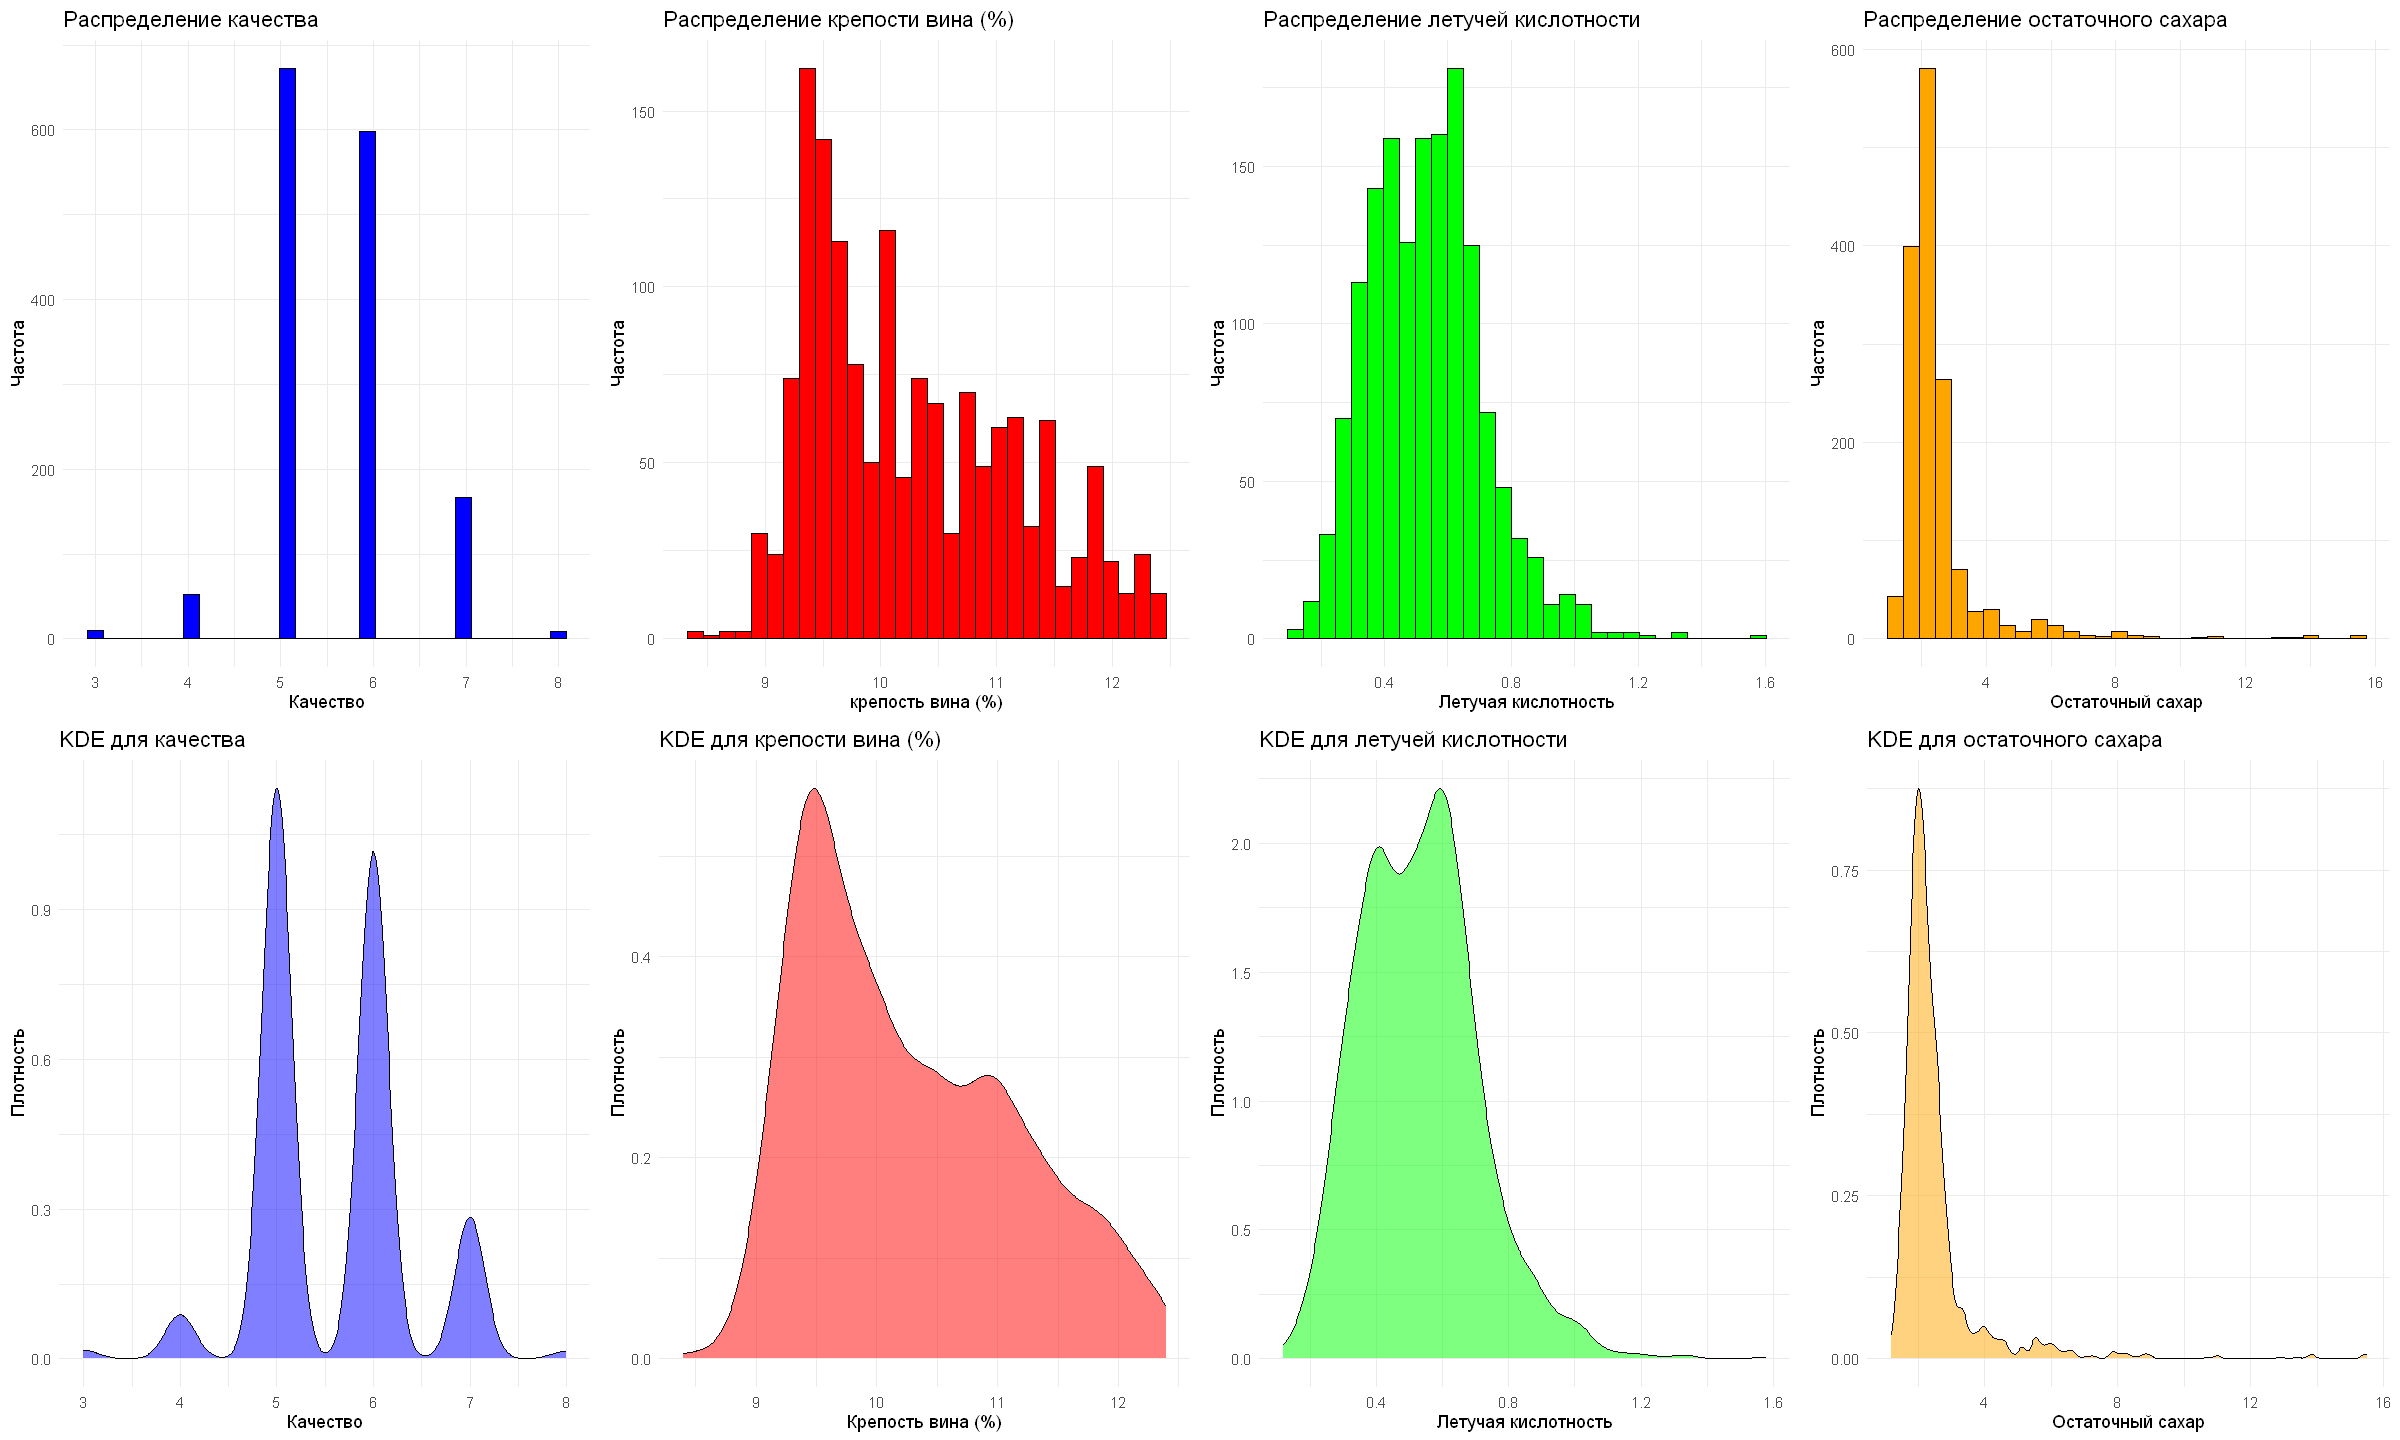

In [11]:
# Фильтрация экстремальных данных диаметра (исключим данные выше 95-го процентила)
alcohol_95 <- quantile(wine_data$alcohol, 0.95)
filtered_data <- wine_data %>% filter(alcohol < alcohol_95)

# Создание гистограмм

options(repr.plot.width = 20, repr.plot.height = 12)

# График распределения качества
p1 <- ggplot(filtered_data, aes(x = quality)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  labs(title = "Распределение качества", x = "Качество", y = "Частота") +
  theme_minimal()

# График распределения алкоголя
p2 <- ggplot(filtered_data, aes(x = alcohol)) +
  geom_histogram(bins = 30, fill = "red", color = "black") +
  labs(title = "Распределение крепости вина (%)", x = "крепость вина (%)", y = "Частота") +
  theme_minimal()

# График распределения летучей кислотности
p3 <- ggplot(filtered_data, aes(x = volatile.acidity)) +
  geom_histogram(bins = 30, fill = "green", color = "black") +
  labs(title = "Распределение летучей кислотности", x = "Летучая кислотность", y = "Частота") +
  theme_minimal()

# График распределения летучей кислотности
p4 <- ggplot(filtered_data, aes(x = residual.sugar)) +
  geom_histogram(bins = 30, fill = "orange", color = "black") +
  labs(title = "Распределение остаточного сахара", x = "Остаточный сахар", y = "Частота") +
  theme_minimal()
# Создание KDE графиков

# График распределения качества KDE
p5 <- ggplot(filtered_data, aes(x = quality)) +
  geom_density(fill = "blue", alpha = 0.5) +
  labs(title = "KDE для качества", x = "Качество", y = "Плотность") +
  theme_minimal()

# График распределения крепости вина (%) с KDE
p6 <- ggplot(filtered_data, aes(x = alcohol)) +
  geom_density(fill = "red", alpha = 0.5) +
  labs(title = "KDE для крепости вина (%)", x = "Крепость вина (%)", y = "Плотность") +
  theme_minimal()

# График распределения летучей кислотности с KDE
p7 <- ggplot(filtered_data, aes(x = volatile.acidity)) +
  geom_density(fill = "green", alpha = 0.5) +
  labs(title = "KDE для летучей кислотности", x = "Летучая кислотность", y = "Плотность") +
  theme_minimal()

# График распределения остаточного сахара с KDE
p8 <- ggplot(filtered_data, aes(x = residual.sugar)) +
  geom_density(fill = "orange", alpha = 0.5) +
  labs(title = "KDE для остаточного сахара", x = "Остаточный сахар", y = "Плотность") +
  theme_minimal()

# Расположение графиков в сетке 2x4
grid.arrange(p1, p2, p3, p4, p5, p6, p7, p8, ncol = 4, nrow = 2)



<h2>Выводы по данным распределения вина</h2>

<h3>Качество:</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение качества вина расположено по центру, что указывает на преобладание вин среднего качества в выборке. Большая часть часть вин имеет качество 5 и 6.</li>
  <li><b>KDE:</b> Плавная кривая плотности подтверждает, что основная часть вин имеет качество в диапазоне от 5 до 7.</li>
</ul>

<h3>Содержание алкоголя (%):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение крепости вина имеет форму, схожую с нормальным, с некоторым смещением влево. Это означает, что большинство dby имеют умеренные значения крепости (около 9-12 %).</li>
  <li><b>KDE:</b> График плотности показывает аналогичное поведение: наибольшая плотность наблюдается в диапазоне 10–12 %, после чего кривая резко спадает как в меньшие, так и в большие значения. Это свидетельствует о том, что более крепкие и слабоалкогольные вина встречаются реже.</li>
</ul>

<h3>Летучая кислотность(г/л):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение летучей кислотности , также похоже на нормальное, с более сильным смещением влево . В выборке преобладают вина с низкими показателями остаточного сахара (2–5). Такие значения типичны для сухих вин.</li>
  <li><b>KDE:</b> График плотности распределения подтверждает высокую концентрацию вин с низкой и средней летучей кислотностью.</li>
</ul>

<h3>Остаточный сахар (г):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение остаточного сахара,похоже на логарифмически нормальное . В выборке преобладают вина с низкими значениями остаточного сахара. Такие значения характерны для сухих вин.</li>
  <li><b>KDE:</b> Плавная кривая плотности демонстрирует, что большая часть вин содержит от 2 до 5 грамм остаточного сахара.</li>
</ul>

<h3>Общие выводы:</h3>
<ul>
  <li>Большая часть вин имеет высокое качество, а также среднюю крепость, что типично для красных сухих вин.</li>
  <li>Основная масса вин в выборке имеет среднее содержание летучей кислотности и низкое сожержание отсаточного сахара что характерно для качественных вин.</li>
</ul>

## 3.Анализ данных

<h2>Исследование связи между качеством вина и его крепостью (%)</h2>

<p>Проанализируем зависимость между <strong>качеством вина</strong> и его <strong>алкогольной крепостью</strong> (%).</p>

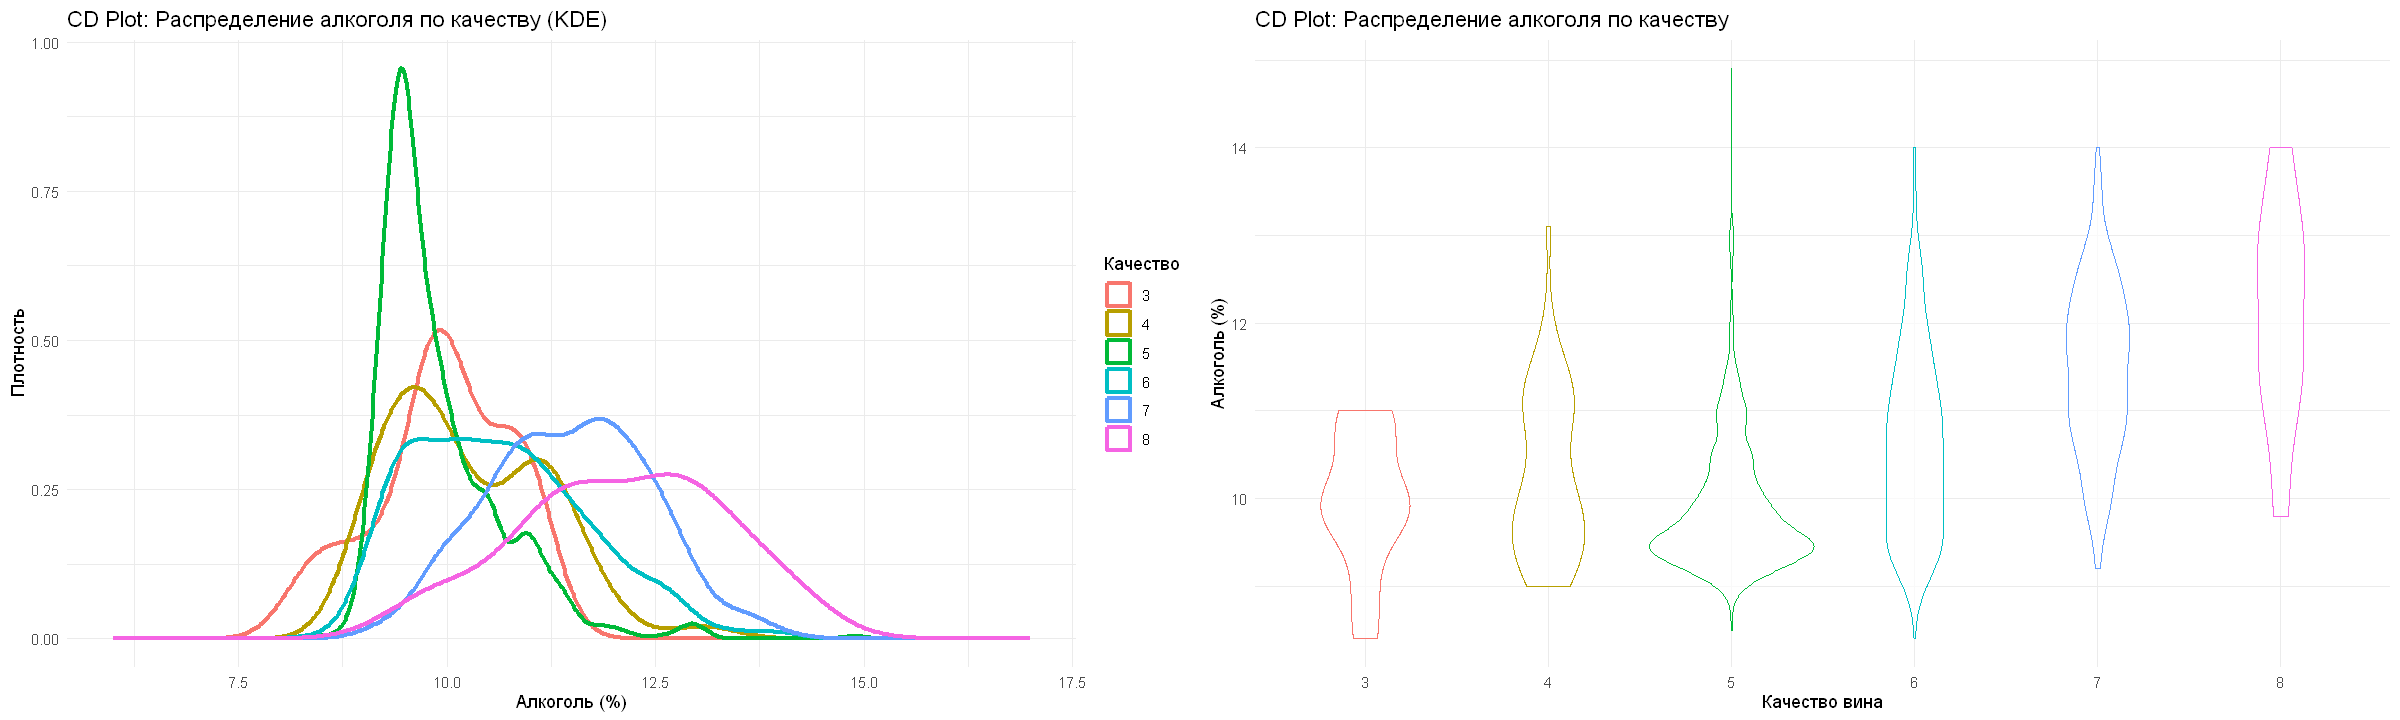

In [13]:
options(repr.plot.width = 20, repr.plot.height = 6)

p1 <- ggplot(wine_data, aes(x = alcohol, color = as.factor(quality))) +
  geom_density(alpha = 0.6, fill = NA, linewidth = 1.2) +
  labs(
    title = "CD Plot: Распределение алкоголя по качеству (KDE)",
    x = "Алкоголь (%)",
    y = "Плотность",
    color = "Качество"
  ) +
  xlim(6, 17) +
  theme_minimal()

p2 <- ggplot(wine_data, aes(x = as.factor(quality), y = alcohol, color = as.factor(quality))) +
  geom_violin(alpha = 0.7, show.legend = FALSE) +
  labs(
    title = "CD Plot: Распределение алкоголя по качеству",
    x = "Качество вина",
    y = "Алкоголь (%)"
  ) +
  theme_minimal()

# Комбинируем графики
grid.arrange(p1, p2, ncol = 2)

<p>Нарисуем 1-й график в большем масштабе<p>

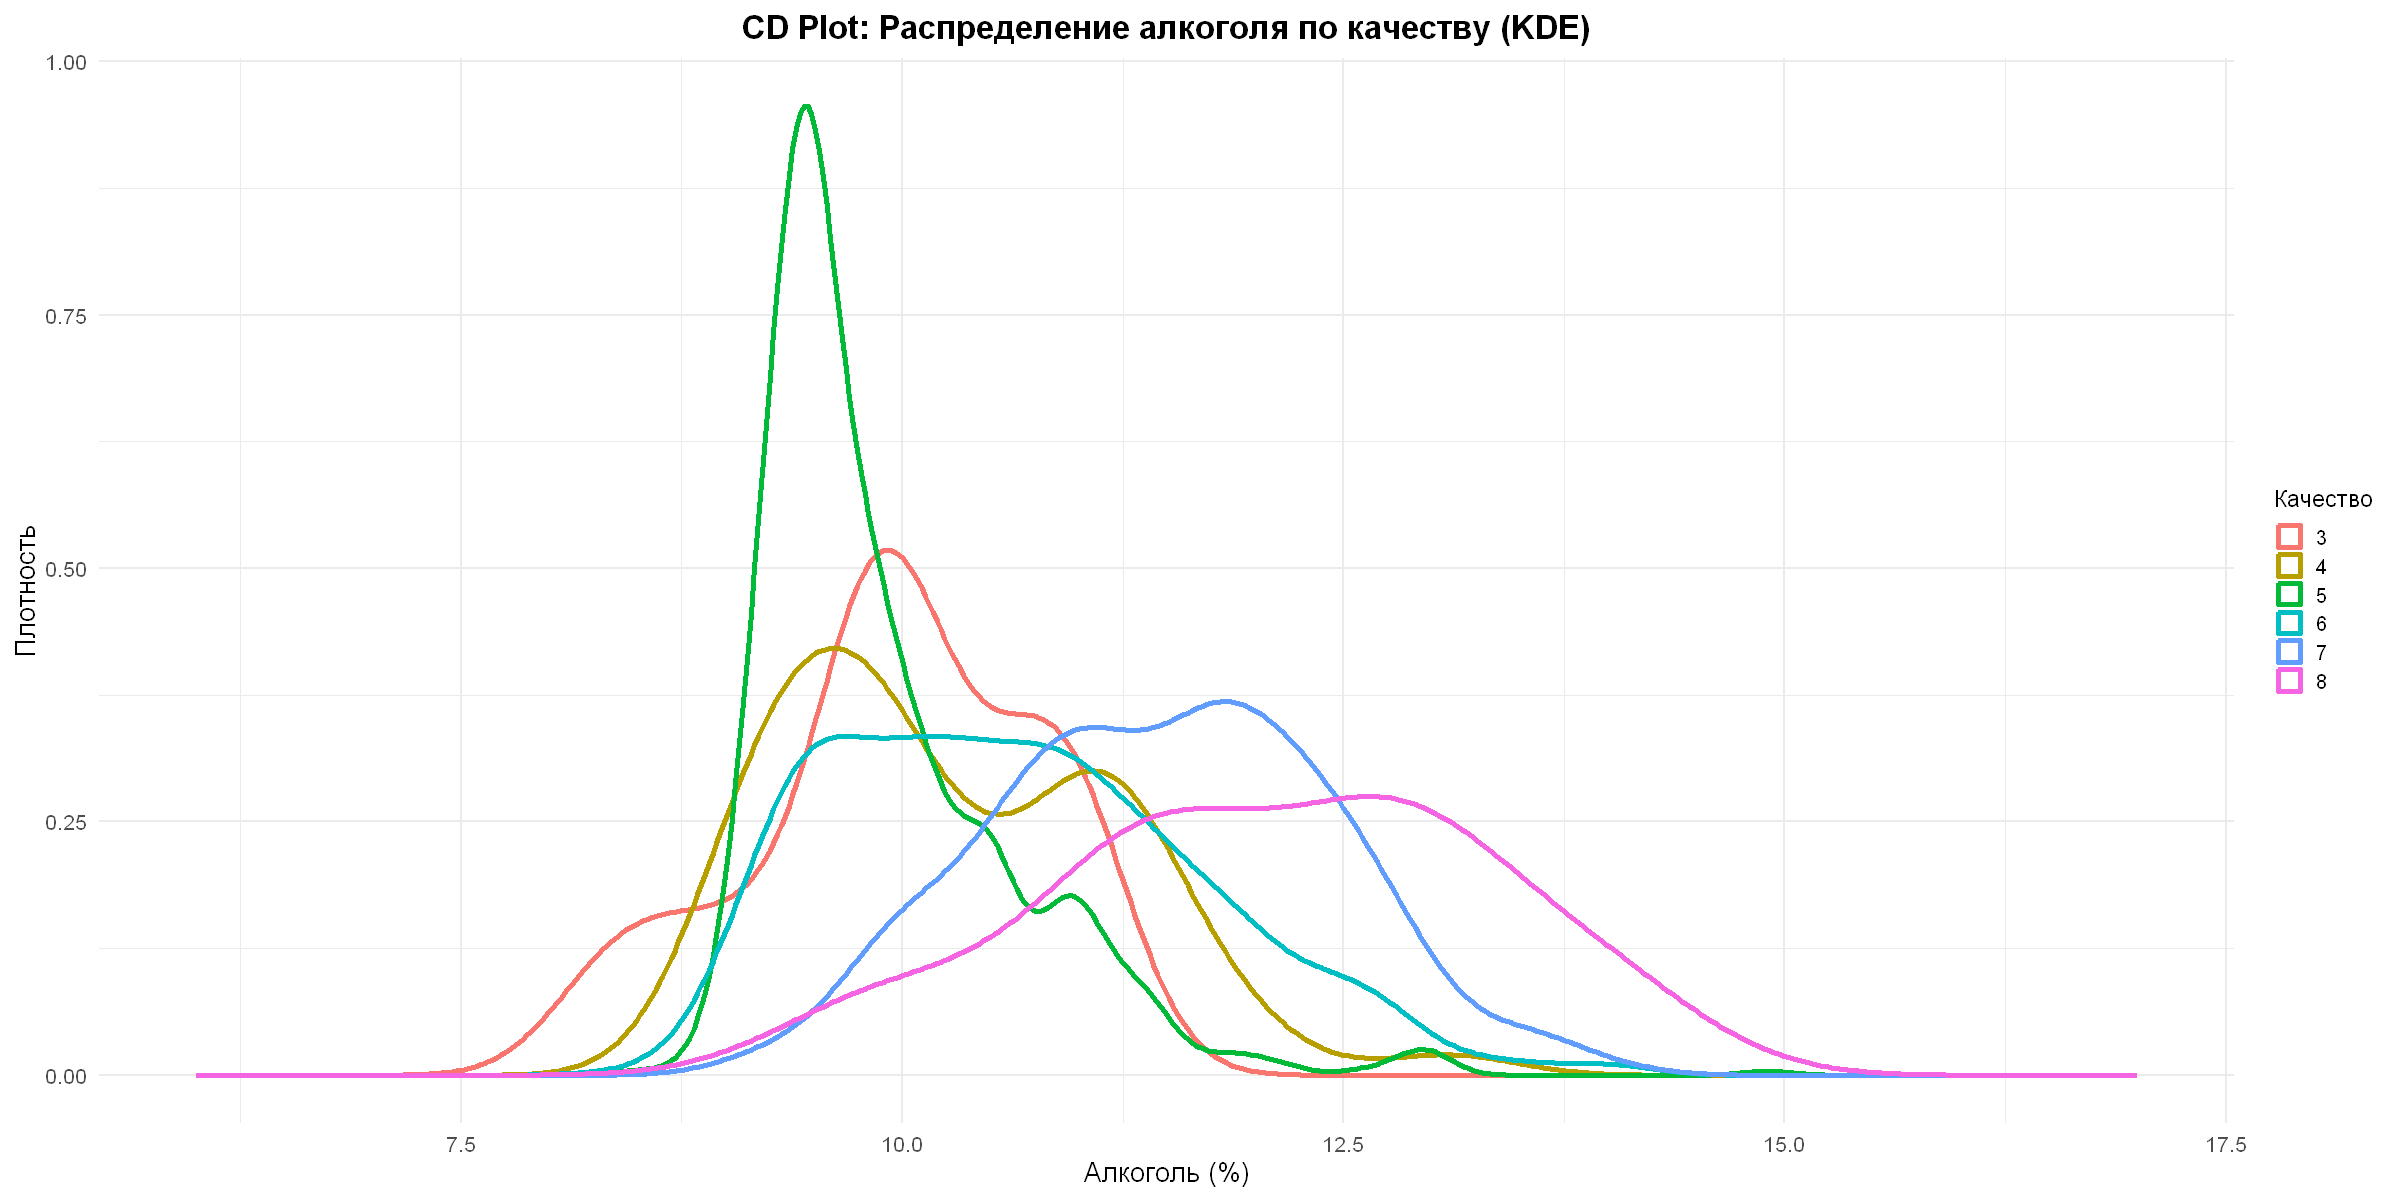

In [7]:
options(repr.plot.width = 20, repr.plot.height = 10)

p1 <- ggplot(wine_data, aes(x = alcohol, color = as.factor(quality))) +
  geom_density(alpha = 0.6, fill = NA, linewidth = 1.5) +
  labs(
    title = "CD Plot: Распределение алкоголя по качеству (KDE)",
    x = "Алкоголь (%)",
    y = "Плотность",
    color = "Качество"
  ) +
  xlim(6, 17) +
  theme_minimal(base_size = 16) +  # Увеличиваем базовый размер шрифта
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 16),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12)
  )

p1

</h3><strong>ВЫВОД:</strong></h3>
<ul>
  <li>Связь между <strong>качеством и крепостью алкоголя — нелинейная</strong>, имеющая форму оптимума (колокола). Качество растет с увеличением алкоголя до определенного предела, после которого дальнейший рост крепости начинает негативно сказываться на сбалансированности и восприятии вина. Большинство вин различного качества имеют крепость 9-14 %.</li>
<ul>

<h2>Исследование связи между остаточный сахором (г) и крепостью вина (%)</h2> <p>Проанализируем зависимость между <strong>остаточный сахором</strong> и <strong>крепостью вина</strong>. Остаточный сахар — это количество сахаров (глюкозы, фруктозы), которые остались в вине после завершения брожения.</p>

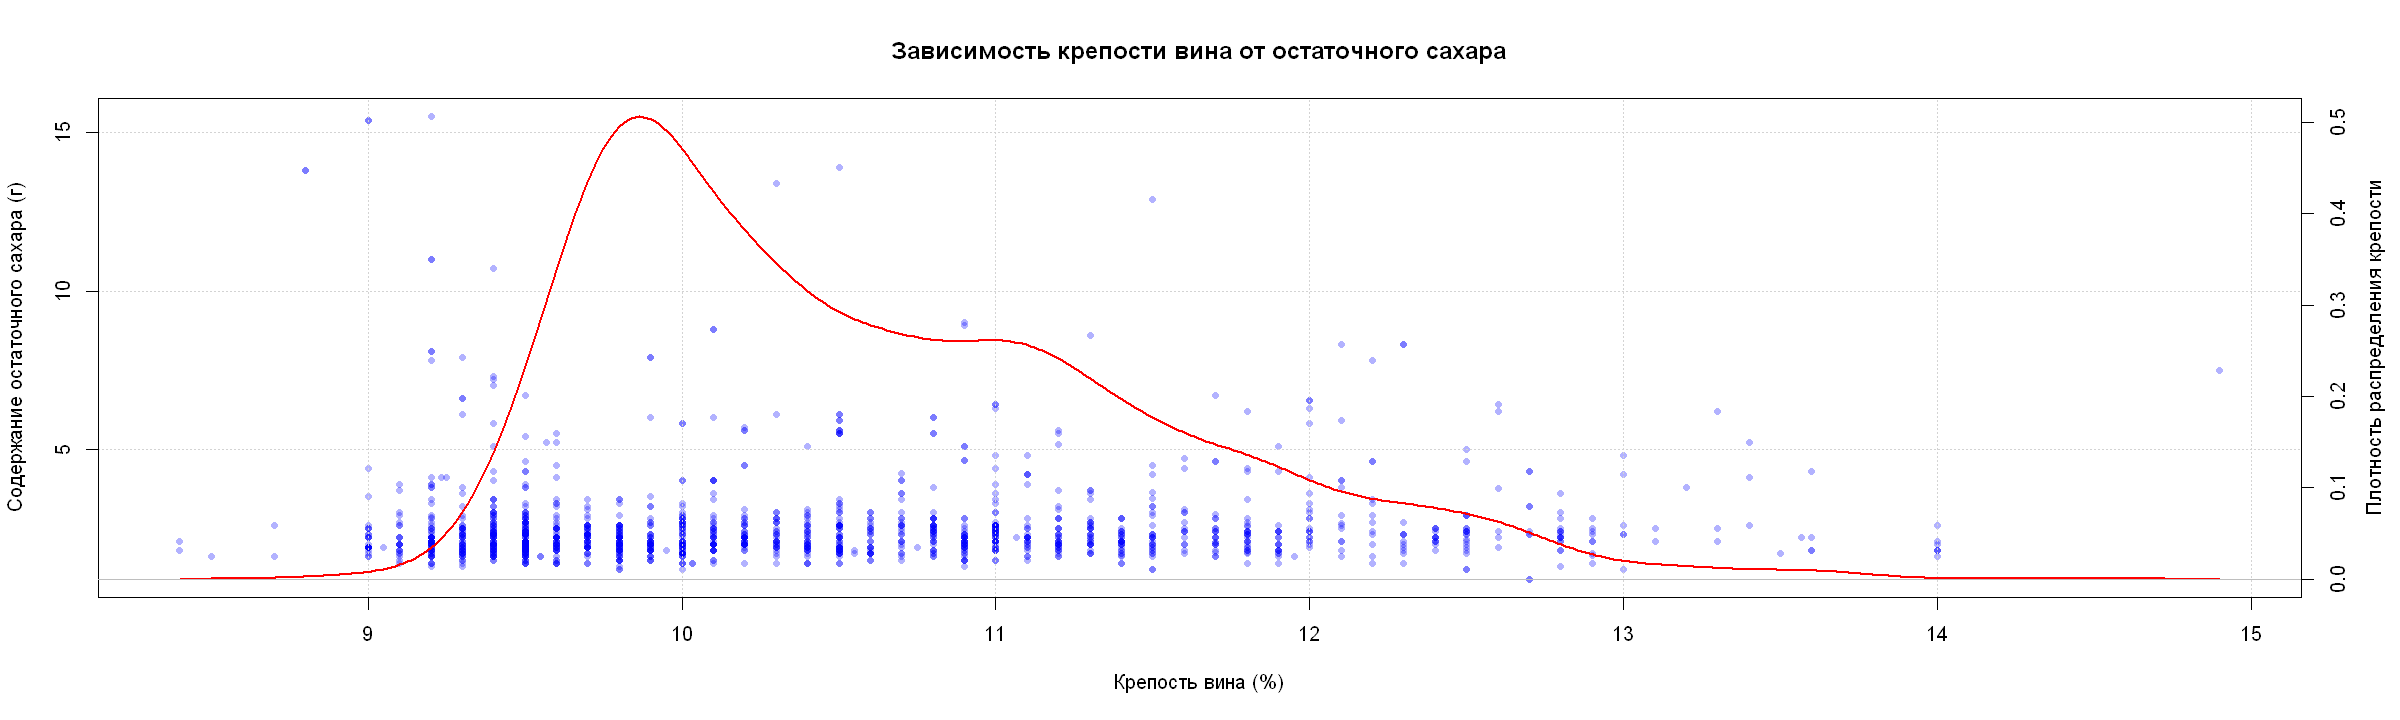

In [18]:
par(mar = c(5, 4, 4, 4) + 0.1)

# Основной график рассеяния
plot(wine_data$alcohol, wine_data$residual.sugar,
     pch = 16, col = rgb(0, 0, 1, 0.3), cex = 0.8,
     xlab = "Крепость вина (%)",
     ylab = "Содержание остаточного сахара (г)",
     main = "Зависимость крепости вина от остаточного сахара")

# Добавляем сетку
grid()

# Добавляем KDE на вторую ось Y с плотностью
par(new = TRUE)
plot(density(wine_data$alcohol), type = "l", col = "red", lwd = 2,
     xaxt = "n", yaxt = "n", #не рисовать оси х и у
     xlab = "", ylab = "",
     main = "")  # Убираем заголовок у второго графика

axis(4)
mtext("Плотность распределения крепости", side = 4, line = 2.5)

<h3>Вывод</h3> <p>На графике видна слабая связь между <strong>крепостью вина</strong>(%) и <strong>содержанием остаточного сахара</strong> (г). Это следует из того что крепость определяется исходной сахаристостью винограда, а "сухость" (низкий остаточный сахар) — полным завершением брожения. Эти два параметра становятся независимыми на финальной стадии приготовления вина.</p>

<h2>Связь между качеством вина и летучей кислотностью</h2> 
<p>Проанализируем зависимость между <strong>качеством</strong> и <strong>летучей кислотностью</strong> вина.<p>

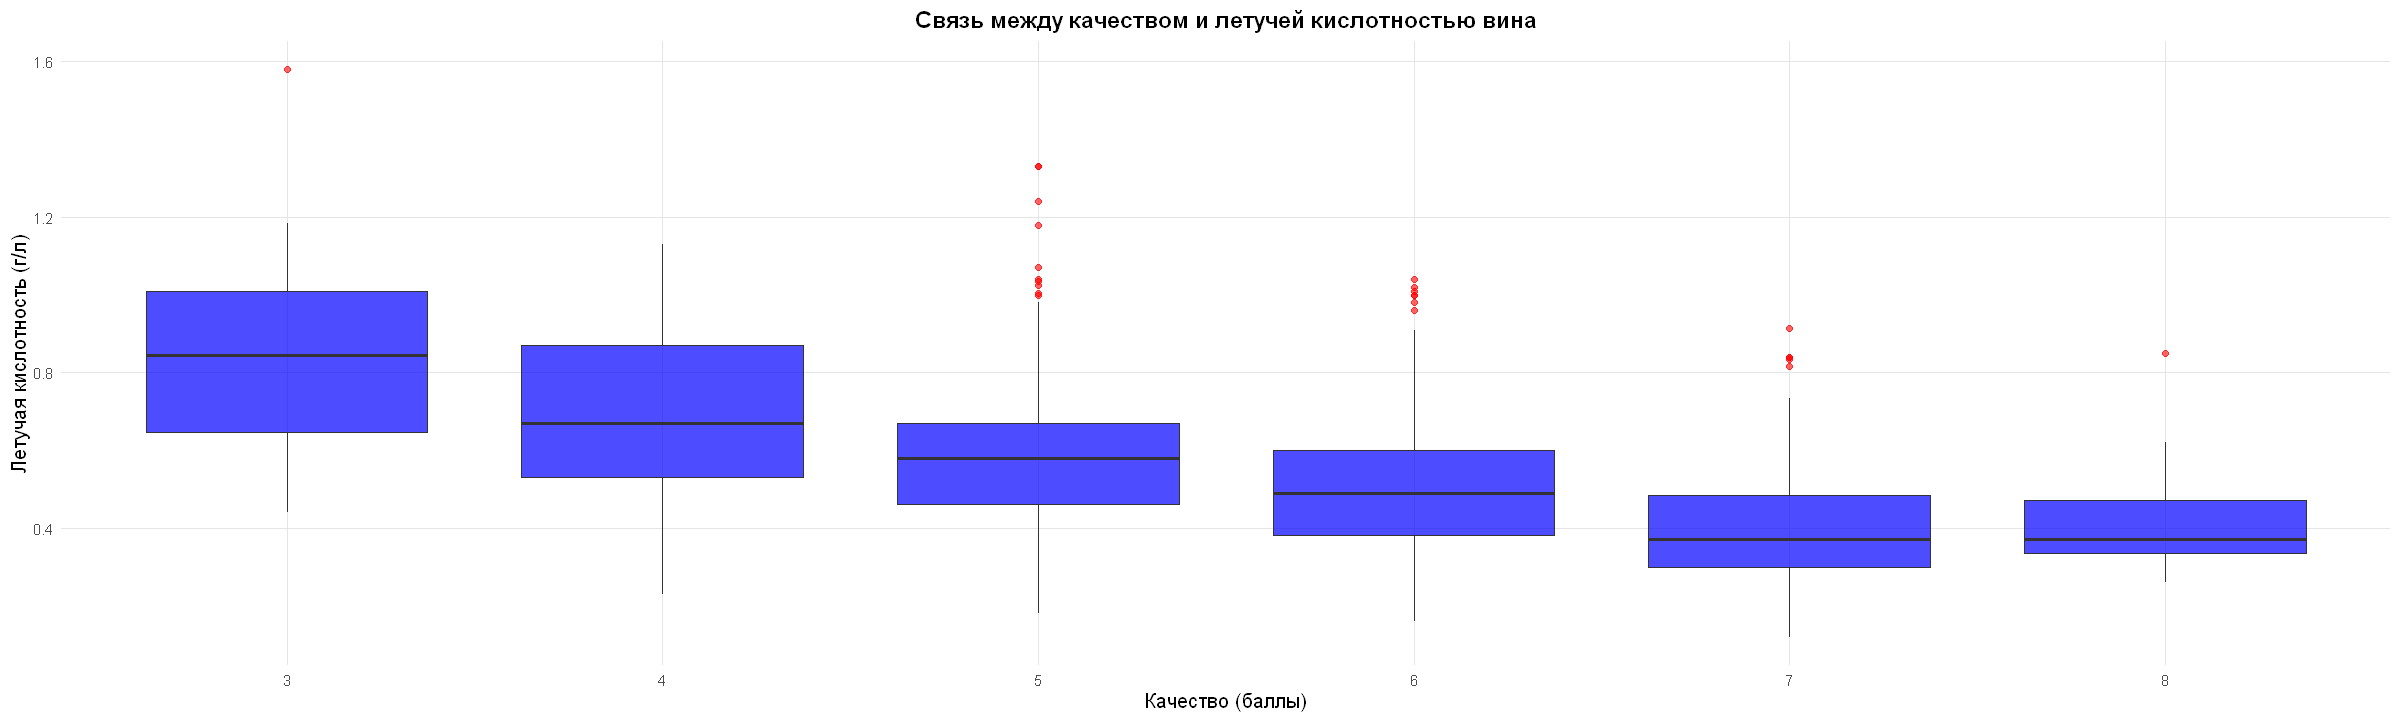

In [20]:
ggplot(wine_data, aes(x = factor(quality), y = volatile.acidity)) +
  geom_boxplot(fill = "blue", alpha = 0.7, outlier.color = "red", outlier.alpha = 0.6) +
  labs(
    title = "Связь между качеством и летучей кислотностью вина",
    x = "Качество (баллы)",
    y = "Летучая кислотность (г/л)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    axis.title = element_text(size = 12),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank()
  )

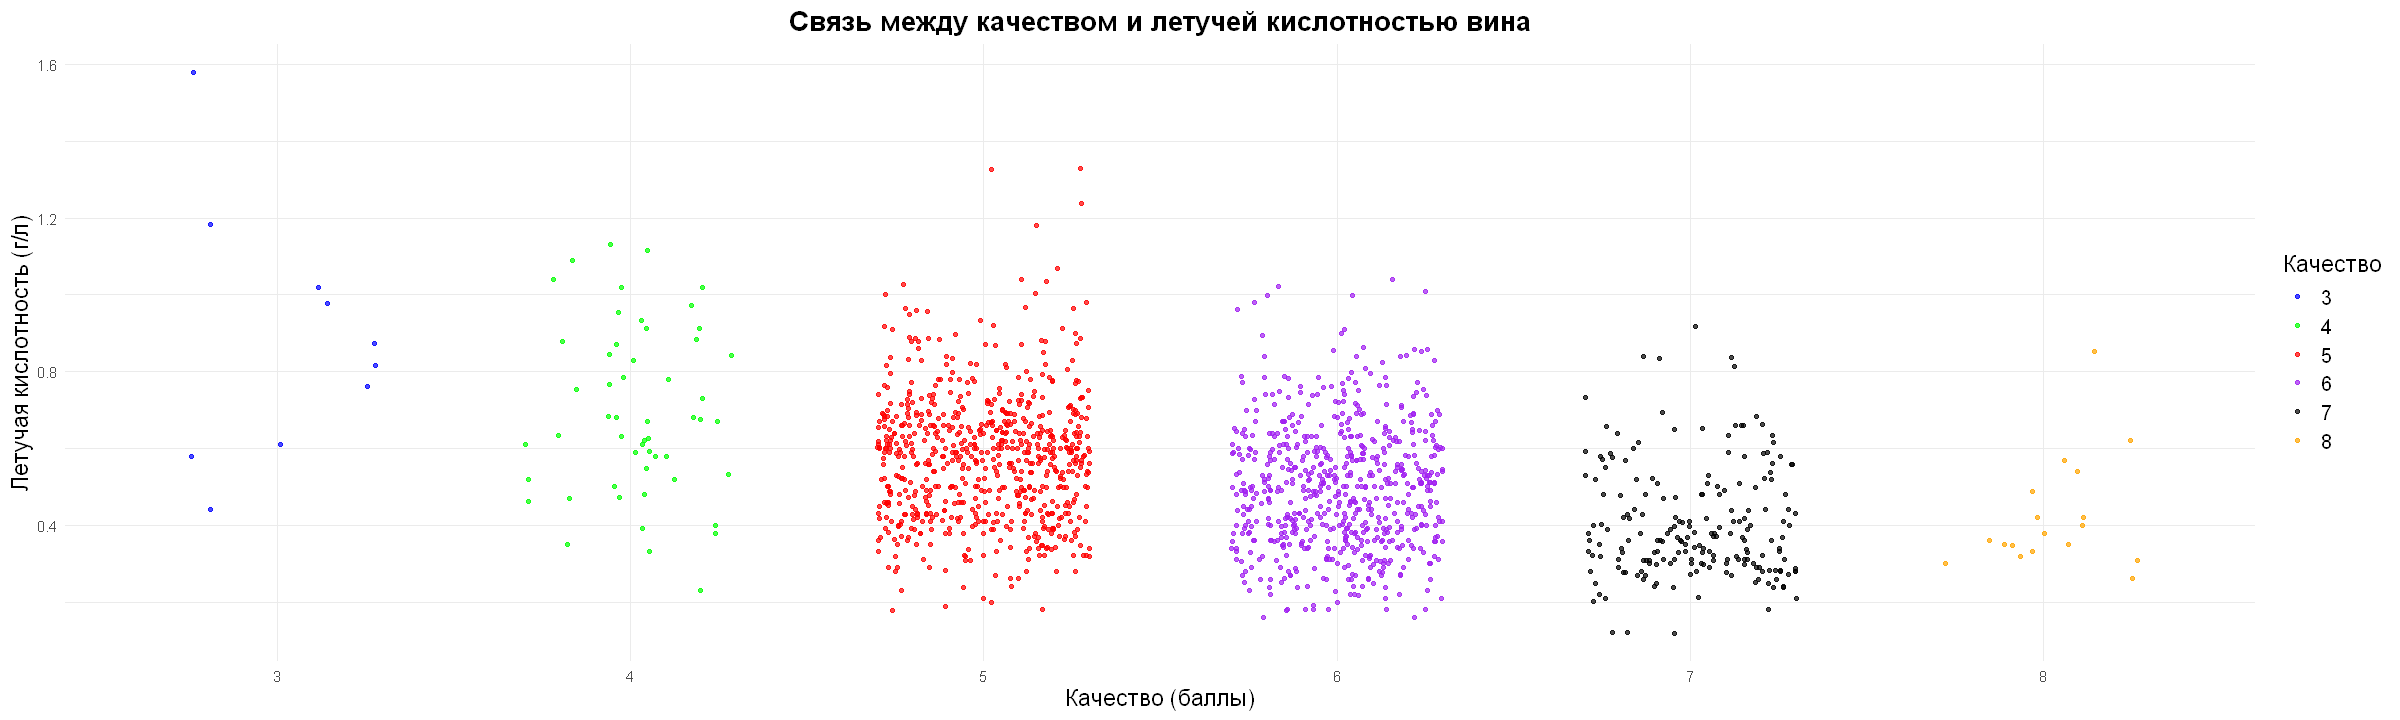

In [21]:
options(repr.plot.width = 20, repr.plot.height = 6)

colors <- c('blue', 'green', 'red', 'purple', 'black', 'orange')

# Создаем stripplot (аналог sns.stripplot)
ggplot(wine_data, aes(x = factor(quality), y = volatile.acidity, color = factor(quality))) +
  geom_jitter(size = 1, alpha = 0.7, width = 0.3) +
  scale_color_manual(values = colors, name = "Качество") +
  labs(
    title = "Связь между качеством и летучей кислотностью вина",
    x = "Качество (баллы)",
    y = "Летучая кислотность (г/л)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    axis.title = element_text(size = 14),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.position = "right"
  )

<h3>Выводы по исследованию связи между качеством и летучей кислотностью вина:</h3>
<ul>
    <li><b>Вина с низким значением качества (3 и 4 балла)</b> имеют более высокое содержание летучей кислотности. Это связано с дешевизной винограда, недостаточно строгим контролем при приготовлении вина.Высокая летучая кислотность - характерный признак для дешевых и не очень качественных вин.</li>
    <li>С увеличением качества вина <b>средняя летучая кислотность уменьшается</b>. Это объясняется тем, что для качетвенных вин используется сырье высшего качества, а на производствах следят за гигиеной и брожением вина.</li>
    <li>Распределение летучей кислотности по качетсву вин показывает наличие разброса, но <b>основные различия наблюдаются между крайними группами</b> (3 — низкое качество и 8 — высокое качество).</li>
</ul>

## 4.Проверка данных на выбросы с использованием тестов Граббса и Q-теста Диксона

<p>Используем два статистических метода: <strong>теста Граббса</strong> и <strong>Q-тест Диксона</strong>. Эти методы направлены на выявление и устранение выбросов — наблюдений, которые значительно отличаются от основной массы данных и могут искажать результаты анализа.</p>

<h3>Тест Граббса</h3>

<p><strong>Тест Граббса</strong> (Grubbs' test), также известный как экстремальный тест, представляет собой мощный метод для обнаружения выбросов в одномерных данных. Этот тест направлен на проверку гипотезы о том, что наиболее экстремальное значение в выборке является выбросом, предполагая, что данные следуют нормальному распределению.</p>

<p>Гипотезы теста Граббса формулируются следующим образом:</p>
<ul>
    <li><strong>Нулевая гипотеза (H<sub>0</sub>):</strong> Все наблюдения принадлежат одной и той же генеральной совокупности, выбросов нет.</li>
    <li><strong>Альтернативная гипотеза (H<sub>1</sub>):</strong> Одно из наблюдений является выбросом.</li>
</ul>

<p>Тест вычисляет статистику Граббса (G), которая определяется по формуле:</p>

$$
G = \frac{\max{|x_i - \bar{x}|}}{s}
$$

<p>где:</p>
<ul>
    <li><em>x<sub>i</sub></em> - подозрительное значение, которое проверяется на выброс;</li>
    <li> $\bar{x}$ - среднее арифметическое выборки;</li>
    <li><em>s</em> - стандартное отклонение выборки.</li>
</ul>

<p>Если рассчитанное значение статистики Граббса превышает критическое значение для данного уровня значимости, то наблюдение считается выбросом. Этот тест особенно эффективен для небольших и средних выборок, когда требуется выявить одиночный выброс.</p>

<h3>Q-тест Диксона</h3>

<p><strong>Q-тест Диксона</strong> (Dixon's Q test) - это непараметрический тест, который применяется для обнаружения выбросов в небольших выборках (обычно менее 30 наблюдений). Метод направлен на выявление экстремальных значений, как максимальных, так и минимальных, и проверяет их на принадлежность к генеральной совокупности.</p>

<p>Для проведения теста вычисляется коэффициент <strong>Q</strong>, который рассчитывается следующим образом:</p>

$$
Q = \frac{x_{ext} - x_{n}}{x_{max} - x_{min}}
$$

<p>где:</p>
<ul>
    <li><em>x<sub>ext</sub></em> — подозрительное экстремальное значение (минимальное или максимальное);</li>
    <li><em>x<sub>n</sub></em> — ближайшее соседнее значение к подозрительному экстремальному значению;</li>
    <li><em>x<sub>max</sub></em> и <em>x<sub>min</sub></em> — максимальное и минимальное значения выборки соответственно.</li>
</ul>

<p>Если рассчитанное значение Q превышает критическое значение для выбранного уровня значимости, то подозрительное значение считается выбросом. Важно отметить, что Q-тест Диксона особенно полезен для анализа малых выборок и может применяться даже в случаях, когда выборка не строго нормальна.</p>

<h3>Обоснование выбора летучей кислотности</h3>

<p>Для анализа выбрана величина <strong>летучей кислотности (г/л)</strong>, поскольку предварительное исследование показало, что её распределение наиболее близко к нормальному среди всех параметров в наборе данных. Это важное условие для корректного применения как теста Граббса, так и Q-теста Диксона, так как оба метода предполагают нормальное распределение данных.</p>

<p>Проверка данных на наличие выбросов с использованием данных методов позволяет повысить точность анализа, обеспечивая чистоту данных и предотвращая возможные искажения, вызванные экстремальными значениями.</p>

In [22]:
library(outliers)

# Инициализация с сохранением индексов
original_values <- wine_data$volatile.acidity
original_indices <- 1:length(original_values)
all_outlier_indices <- c()
alpha <- 0.05

# Создаем временные переменные для работы
current_values <- original_values
current_indices <- original_indices

# Цикл для поиска выбросов
repeat {
  test <- grubbs.test(current_values, type = 10)  # тест на один выброс
  
  if (test$p.value < alpha) {
    # Определяем индекс выброса
    if (abs(min(current_values) - mean(current_values)) > abs(max(current_values) - mean(current_values))) {
      outlier_index <- which.min(current_values)
    } else {
      outlier_index <- which.max(current_values)
    }
    
    # Сохраняем оригинальный индекс строки
    original_outlier_index <- current_indices[outlier_index]
    all_outlier_indices <- c(all_outlier_indices, original_outlier_index)
    
    # Удаляем выброс из текущих данных
    current_values <- current_values[-outlier_index]
    current_indices <- current_indices[-outlier_index]
  } else {
    break
  }
}

# Получаем строки с выбросами
outliers_df <- wine_data[all_outlier_indices, ]

# Результаты
cat("Номера строк с выбросами:", all_outlier_indices, "\n")

Номера строк с выбросами: 1300 127 128 673 


<table border="1" cellpadding="5" cellspacing="0">
  <tr>
    <th>Номер объекта</th>
    <th>Летучая кислотность (г/м)</th>
    <th>качество</th>
    <th>Содержание алкоголя (%)</th>
    <th>Остаточный сахар(г)</th>
  </tr>
  <tr>
    <td>127</td>
    <td>1.33</td>
    <td>5</td>
    <td>10.9</td>
    <td>1.7</td>
  </tr>
  <tr>
    <td>128</td>
    <td>1.33</td>
    <td>5</td>
    <td>10.9</td>
    <td>1.8</td>
  </tr>
  <tr>
    <td>673</td>
    <td>1.24</td>
    <td>5</td>
    <td>9.5</td>
    <td>2.0</td>
  </tr>
  <tr>
    <td>1300</td>
    <td>1.58</td>
    <td>3</td>
    <td>10.9</td>
    <td>2.1</td>
  </tr>
</table>

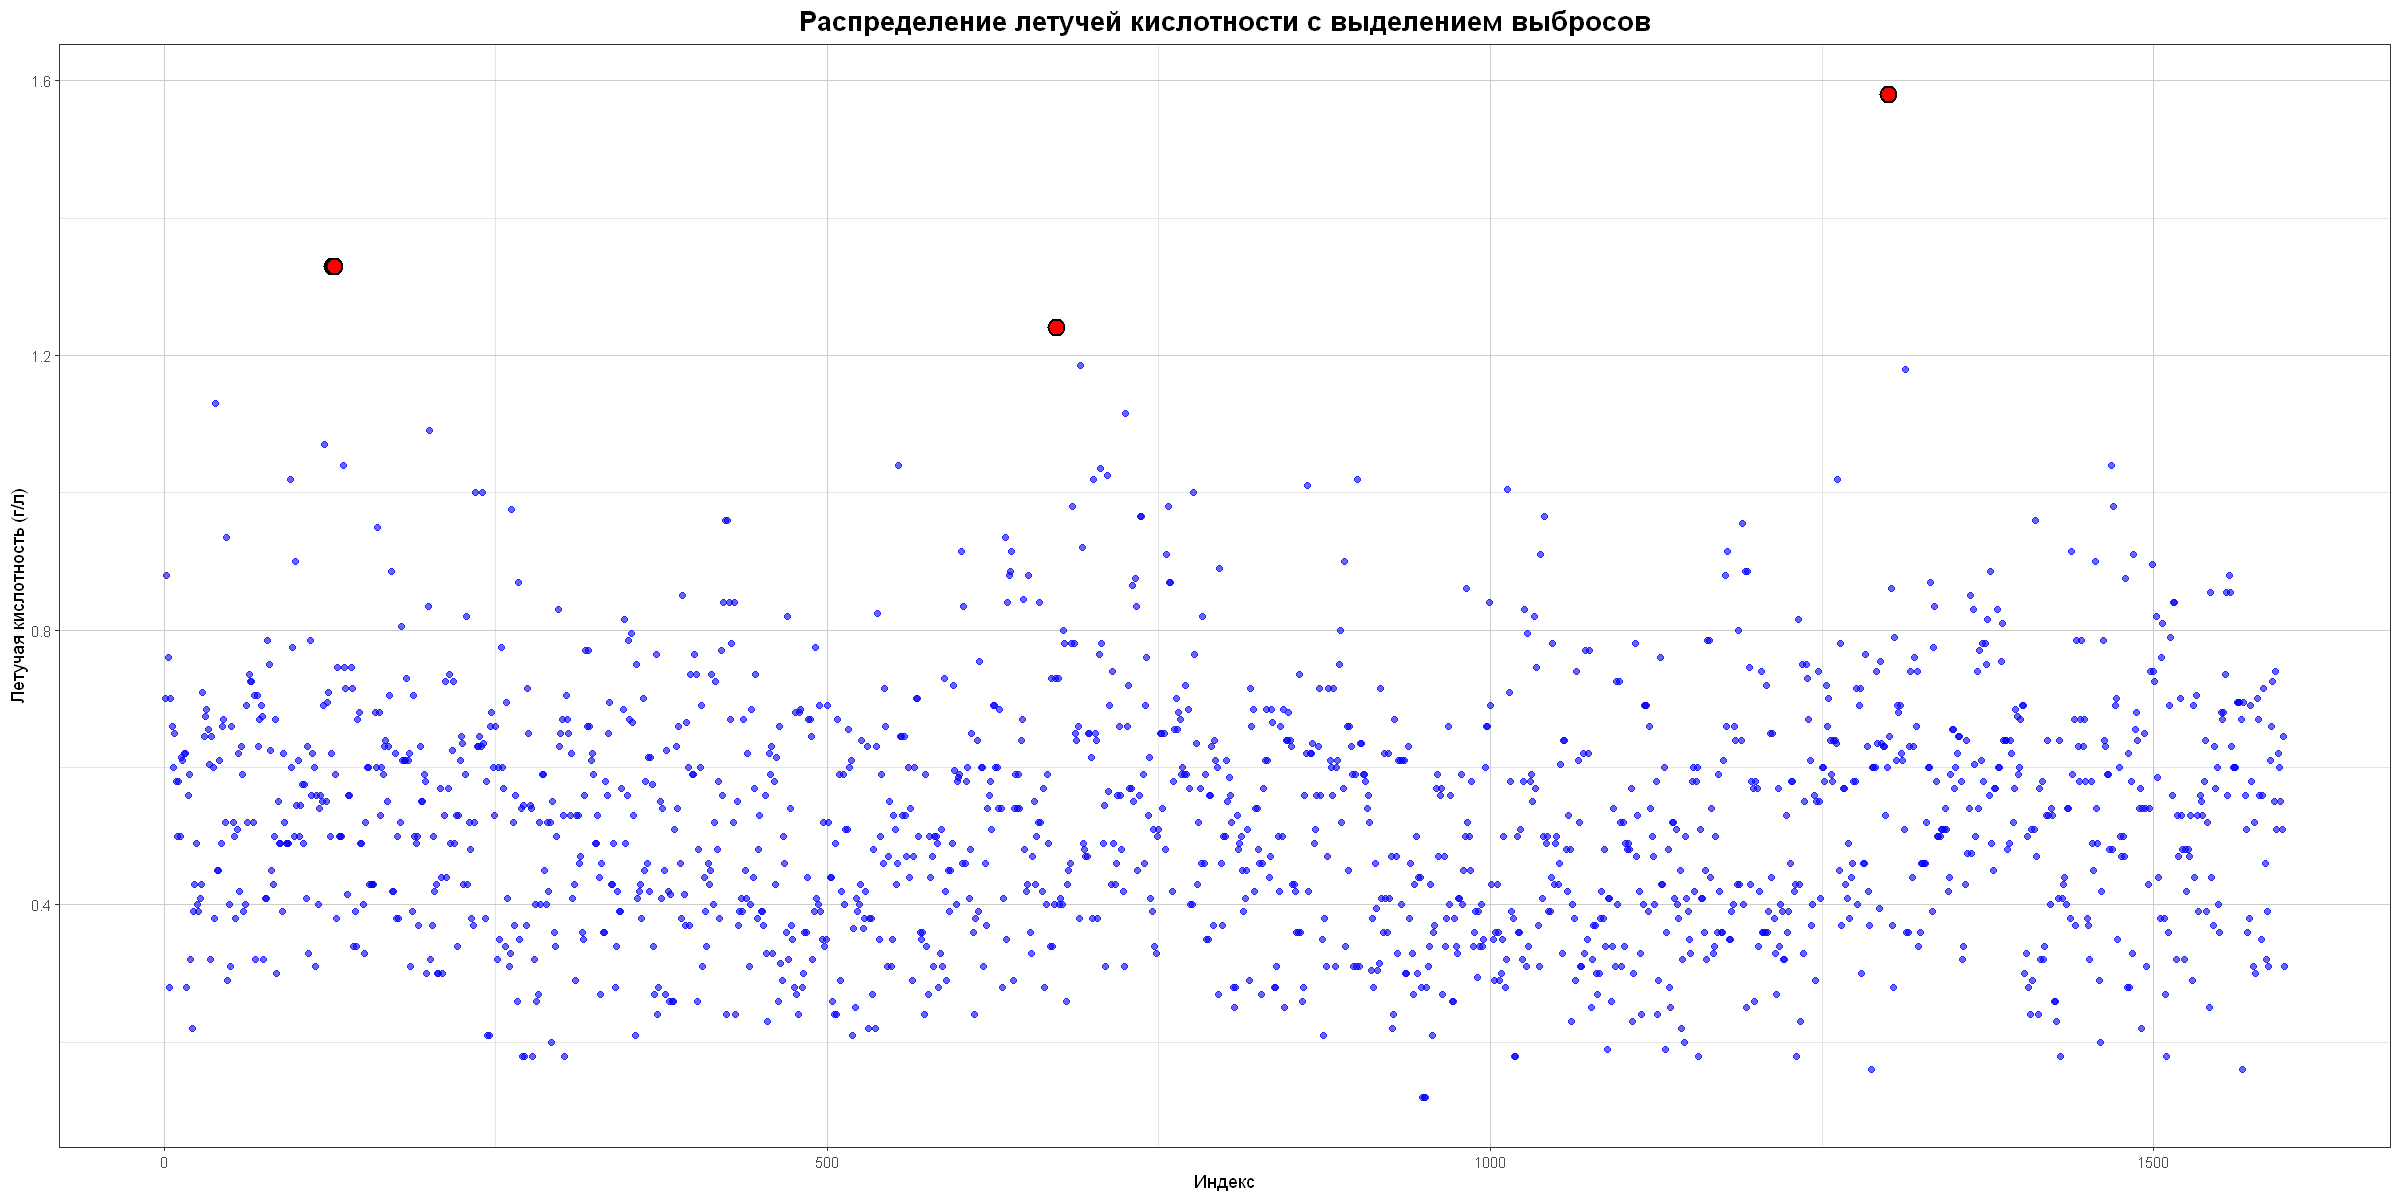

In [23]:
options(repr.plot.width = 20, repr.plot.height = 10)

# Создаем вектор с индексами выбросов
outlier_indices <- c(127, 128, 673, 1300)

library(ggplot2)

# Создаем отдельный dataframe с выбросами
outliers_df <- wine_data[outlier_indices, ]

ggplot() +
  # Все данные синим
  geom_point(data = wine_data, 
             aes(x = 1:nrow(wine_data), y = volatile.acidity),
             color = "blue", alpha = 0.6, size = 1.5) +
  # Выбросы красным с черной обводкой
  geom_point(data = outliers_df,
             aes(x = outlier_indices, y = volatile.acidity),
             color = "black", fill = "red", 
             size = 4, shape = 21, stroke = 1.2) +
  labs(
    title = "Распределение летучей кислотности с выделением выбросов",
    x = "Индекс",
    y = "Летучая кислотность (г/л)"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    panel.grid.major = element_line(color = "grey80"),
    panel.grid.minor = element_line(color = "grey90")
  )

<h2>Вывод по результатам применения теста Граббса</h2>

<p>В результате применения теста Граббса к распределению летучей кислотности были выявлены следующие наблюдения, которые можно считать выбросами:

<p>Эти объекты имеют значения летучей кислотности вина, которые значительно отличаются от среднего по выборке, что указывает на их статус как выбросов.</p>

<p>Анализ показал, что среди выбросов находятся только вина с высокой летучей кислотностью. И все эти вина имеют качество не выше 5</p></p>

<h2> Q-тест Диксона </h2>

In [24]:
dixon_test <- function(data_vector) {
  n <- length(data_vector)
  sorted_data <- sort(data_vector)
  
  # Вычисляем Q-статистики
  q_min <- (sorted_data[2] - sorted_data[1]) / (sorted_data[n] - sorted_data[1])
  q_max <- (sorted_data[n] - sorted_data[n-1]) / (sorted_data[n] - sorted_data[1])
  
  # Критическое значение для alpha = 0.05
  q_crit <- 0.260
  
  min_outlier <- q_min > q_crit
  max_outlier <- q_max > q_crit
  
  return(list(min_outlier = min_outlier, max_outlier = max_outlier))
}

# Получаем уникальные значения летучей кислотности
unique_volatile_acidity_values <- unique(wine_data$volatile.acidity)

# 30 наименьших и 30 наибольших уникальных значений
smallest_unique_volatile_acidity <- sort(unique_volatile_acidity_values)[1:30]
largest_unique_volatile_acidity <- sort(unique_volatile_acidity_values)[(length(unique_volatile_acidity_values)-29):length(unique_volatile_acidity_values)]

# Применяем тест Диксона
result_max <- dixon_test(largest_unique_volatile_acidity)
result_min <- dixon_test(smallest_unique_volatile_acidity)

# Выводим результаты
cat("Для 30 наибольших значений:\n")
cat("Минимальный выброс:", result_max$min_outlier, "\n")
cat("Максимальный выброс:", result_max$max_outlier, "\n\n")

cat("Для 30 наименьших значений:\n")
cat("Минимальный выброс:", result_min$min_outlier, "\n")
cat("Максимальный выброс:", result_min$max_outlier, "\n")

Для 30 наибольших значений:
Минимальный выброс: FALSE 
Максимальный выброс: TRUE 

Для 30 наименьших значений:
Минимальный выброс: FALSE 
Максимальный выброс: FALSE 


<h2> Расшифровка результатов Q-теста </h2>

<p>Среди 30 наименьших значений летучей кислотности выбросов нет (Два нижних False). Среди 30 наибольших значений летучей кислотности выброс есть. <strong>Самый большой элемент в этой группе ЯВЛЯЕТСЯ выбросом</strong></p>

In [25]:
largest_values <- sort(unique_volatile_acidity_values)[(length(unique_volatile_acidity_values)-29):length(unique_volatile_acidity_values)]
cat("Выброс (наибольшее):", largest_values[length(largest_values)], "\n")

Выброс (наибольшее): 1.58 


In [26]:
largest_unique_volatile_acidity <- sort(unique_volatile_acidity_values)[
  (length(unique_volatile_acidity_values)-30):(length(unique_volatile_acidity_values)-1)
]

# Применяем тест Диксона
result_max <- dixon_test(largest_unique_volatile_acidity)

# Выводим результаты
cat("Минимальный выброс:", result_max$min_outlier, "\n")
cat("Максимальный выброс:", result_max$max_outlier, "\n")

Минимальный выброс: FALSE 
Максимальный выброс: FALSE 


<p>Если рассмотреть с 31 по 2 (Исключая наибольшее , которое оказалось выбросом) вина с наибольшей концентрацией летучей кислотности, то Q-тест наличие выбросов не показывает</p>

## 5.Методы восстановления пропусков в данных

<p>Восстановление пропущенных данных — важная задача при обработке данных. Для этого могут использоваться различные подходы, имеющие различные преимущества и недостатки. В данном примере мы рассмотрим три основных метода заполнения пропусков: с использованием среднего значения, линейной интерполяции и медианы.</p>

<h3>1. Заполнение среднего значения</h3>
<p>Метод заполнения пропусков средним значением является одним из самых простых и распространённых. В этом подходе пропущенные значения заменяются средним значением всех доступных данных в столбце. Это эффективно для случаев, когда данные распределены равномерно и пропуски незначительны, но может приводить к значительным ошибкам, если данные содержат выбросы или сильно варьируются.</p>

<h3>2. Линейная интерполяция</h3>
<p>Линейная интерполяция заполняет пропуски, предполагая, что значения между известными точками изменяются линейно. Для каждого пропуска находятся ближайшие значения до и после пропуска, и на их основе строится прямая линия. Пропущенное значение рассчитывается как точка на этой линии. Этот метод подходит для данных, которые изменяются плавно и без резких скачков.</p>

<h3>3. Заполнение медианным значением</h3>
<p>Медианное значение часто используется для заполнения пропусков, когда данные содержат выбросы или асимметричны. В этом методе пропуски заполняются значением, которое находится посередине всех имеющихся данных (медиана). Это позволяет избежать влияния крайних значений на восстановленные данные, делая этот метод более устойчивым по сравнению со средним значением.</p>

<p>Каждый из этих методов необходимо применять в разных ситуациях, и выбор подхода зависит от характера данных и количества пропусков. Искуственно создадим пропуски в данных о крепости вина и сравним результаты восстановления пропусков с использованием всех трёх методов и оценим их точность.</p>

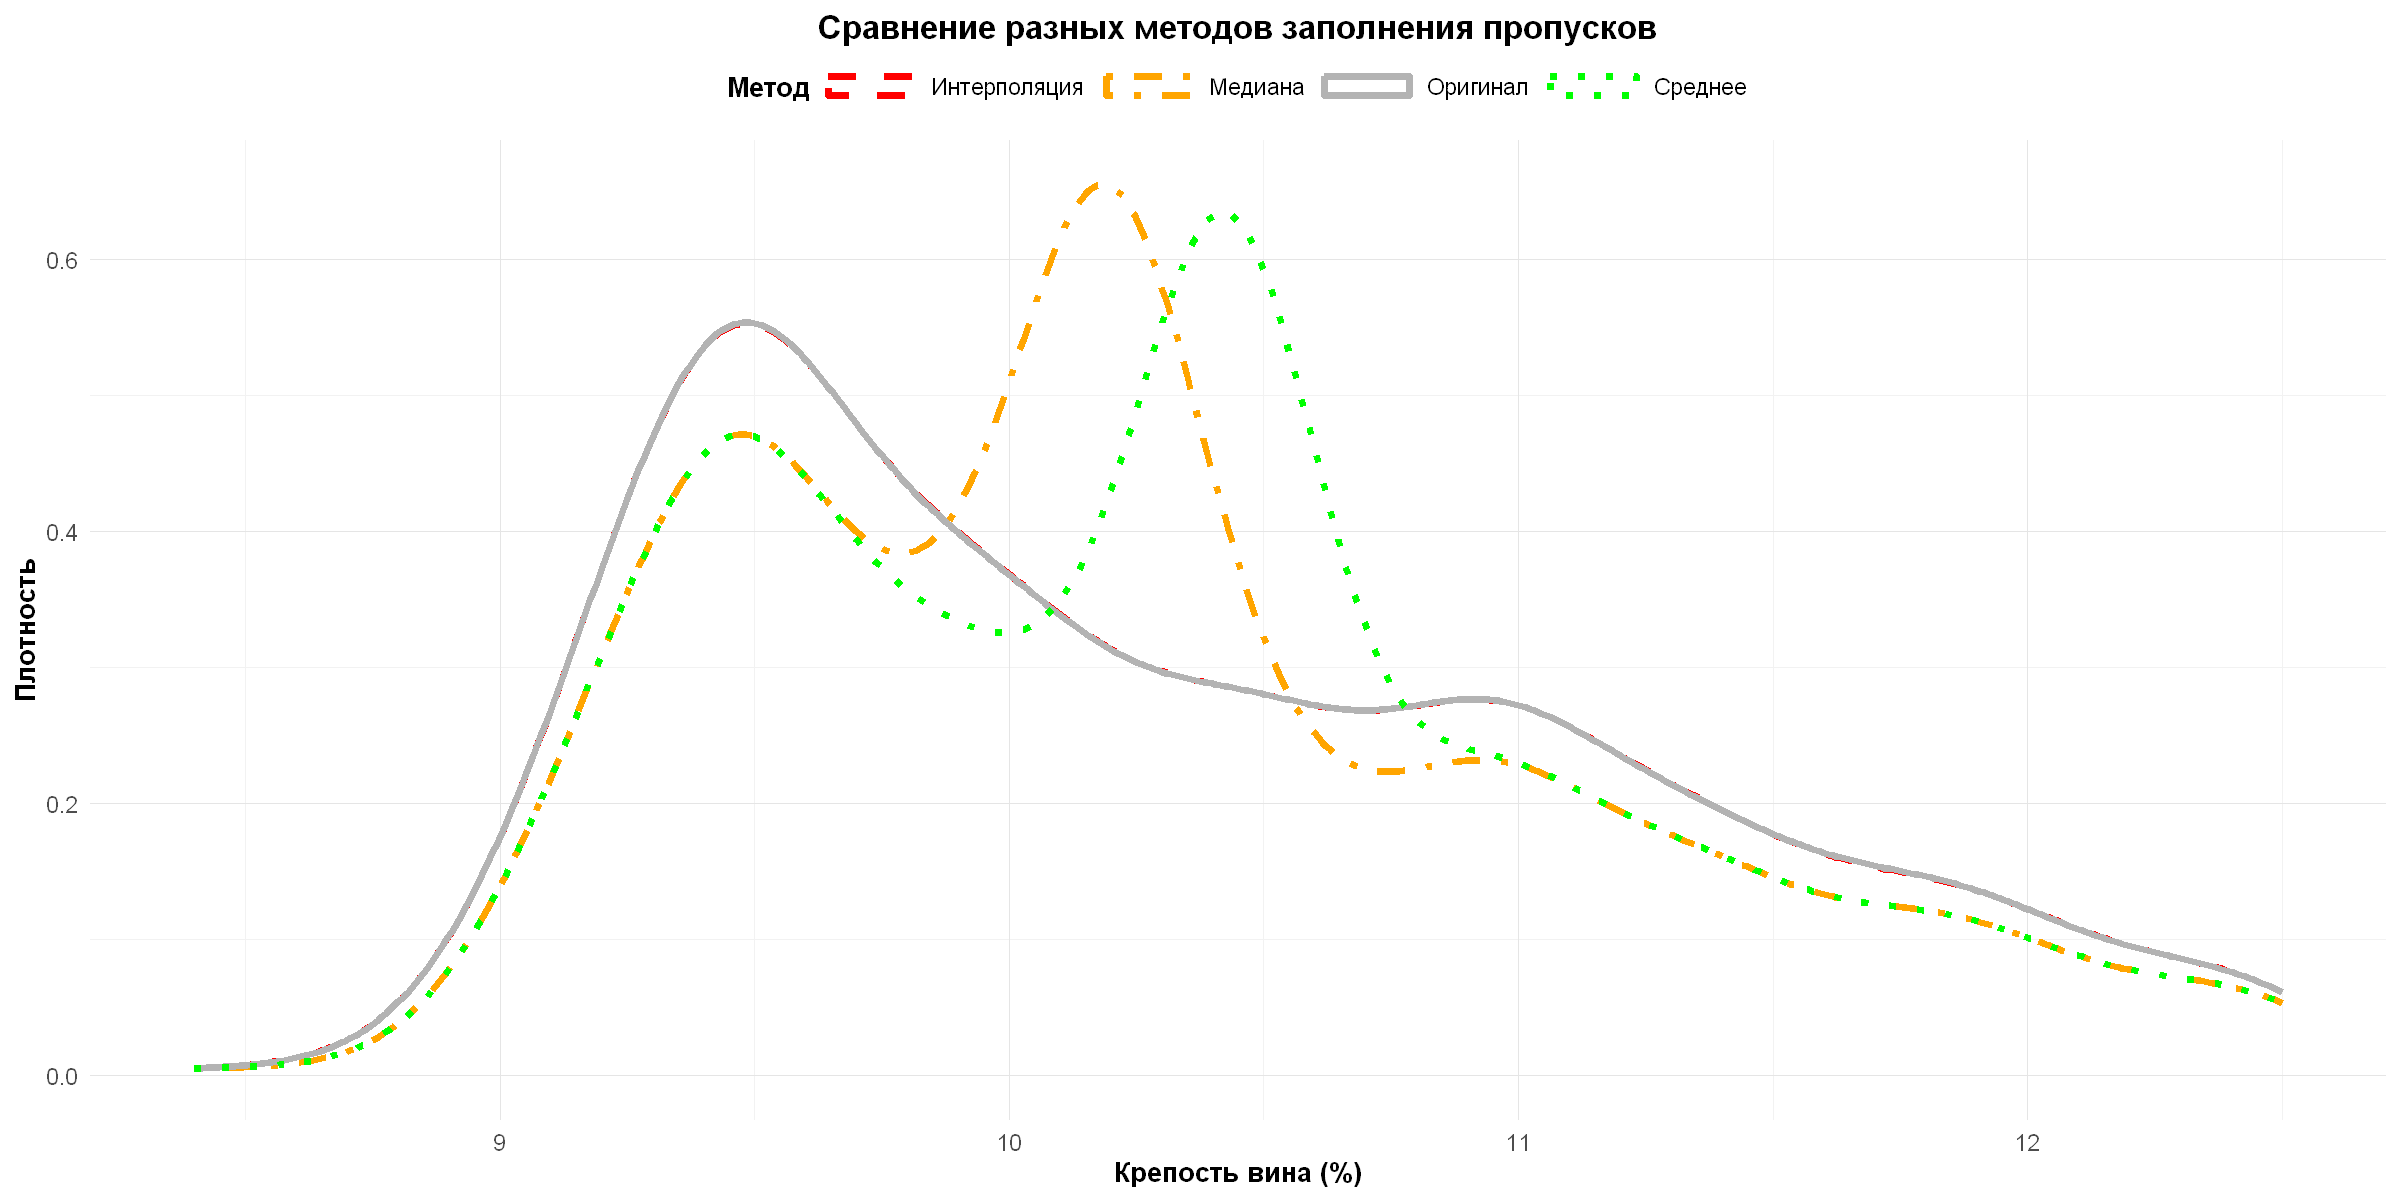

In [28]:
alcohol_data <- sort(wine_data$alcohol)

# Создаем пропуски (каждый 6-й элемент заменяем на NA)
alcohol_data_with_nans <- alcohol_data
alcohol_data_with_nans[seq(0, length(alcohol_data_with_nans), by = 6)] <- NA

# Заполняем пропуски разными методами
mean_filled <- alcohol_data_with_nans
mean_filled[is.na(mean_filled)] <- mean(alcohol_data_with_nans, na.rm = TRUE)

median_filled <- alcohol_data_with_nans
median_filled[is.na(median_filled)] <- median(alcohol_data_with_nans, na.rm = TRUE)

# Интерполяция
interpolated_filled <- approx(1:length(alcohol_data_with_nans), 
                             alcohol_data_with_nans, 
                             xout = 1:length(alcohol_data_with_nans))$y

# Вычисляем 95-й перцентиль
quantile_95 <- quantile(alcohol_data, 0.95)

# Фильтруем данные по 95-му перцентилю
alcohol_data_95 <- alcohol_data[alcohol_data <= quantile_95]
mean_filled_95 <- mean_filled[mean_filled <= quantile_95]
median_filled_95 <- median_filled[median_filled <= quantile_95]
interpolated_filled_95 <- interpolated_filled[interpolated_filled <= quantile_95]

# Создаем dataframe для ggplot
plot_data <- data.frame(
  value = c(alcohol_data_95, mean_filled_95, median_filled_95, interpolated_filled_95),
  method = rep(c("Оригинал", "Среднее", "Медиана", "Интерполяция"), 
               c(length(alcohol_data_95), length(mean_filled_95), 
                 length(median_filled_95), length(interpolated_filled_95)))
)

# Создаем график
ggplot(plot_data, aes(x = value, color = method, linetype = method)) +
  geom_density(size = 2.0, alpha = 0.7) +
  scale_color_manual(values = c("Оригинал" = "gray70",
                               "Среднее" = "green", 
                               "Медиана" = "orange", 
                               "Интерполяция" = "red")) +
  scale_linetype_manual(values = c("Оригинал" = "solid",
                                  "Среднее" = "dotted",
                                  "Медиана" = "dotdash",
                                  "Интерполяция" = "dashed")) +
  labs(
    title = "Сравнение разных методов заполнения пропусков",
    x = "Крепость вина (%)",
    y = "Плотность",
    color = "Метод",
    linetype = "Метод"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 14),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 14),
    legend.position = "top",
    legend.key.width = unit(2, "cm"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey95", linewidth = 0.3)
  )

In [30]:
# Находим индексы пропущенных значений
nan_indices <- which(is.na(alcohol_data_with_nans))

# Вычисляем ошибки для каждого метода
mean_error <- mean(abs(mean_filled[nan_indices] - alcohol_data[nan_indices]))
median_error <- mean(abs(median_filled[nan_indices] - alcohol_data[nan_indices]))
interpolation_error <- mean(abs(interpolated_filled[nan_indices] - alcohol_data[nan_indices]))

cat(round(mean_error, 4), " , ", round(median_error, 4), " , ", round(interpolation_error, 4), "\n")

0.8747  ,  0.8571  ,  0.0027 


Средняя ошибка при заполнении пропусков: <ul> <li>Среднее значение: <strong>0.8747</strong></li> <li>Медиана: <strong>0.8571</strong></li> <li>Линейная интерполяция: <strong>0.0027</strong> (наиболее точный метод)</li> </ul> </li> </ul> <p>Из полученных результатов видно, что линейная интерполяция дает наименьшую среднюю ошибку, что свидетельствует о её высокой точности в случае частых пропусков в наборе данных.

Заметим, что при более редких пропусках метод среднего значения и интегрполяции будет приближаться к реальной плотности распределения данных</p>

## 6.Анализ данных с помощью графиков квантилей, метода огибающих и эмпирической функции распределения стандартных процедур проверки гипотез о нормальности (сгенерированные данные из нормального распределения)

In [32]:
# Генерация нормально распределенных данных
# rnorm(n, mean, sd)
# n - размер выборки
# mean - среднее значение (центр распределения)  
# sd - стандартное отклонение (разброс данных)

data1 <- rnorm(200, 0, 1)
data2 <- rnorm(200, 0, 2)  
data3 <- rnorm(2000, 0, 1)
data4 <- rnorm(2000, 2, 1)

### Эмпирические функции распределения

<h4>Описание метода эмпирической функции распределения</h4>

<p><strong>Эмпирическая функция распределения</strong> - это непараметрическая оценка теоретической функции распределения, построенная непосредственно по выборке.

Для выборки Х1, Х2 ... Хn эмпирическая функция распределения F<sub>n</sub>(X) строится по формуле:$$F_n(X) = \frac{1}{n} \sum_{i=1}^{n} I_{X_i \leq X}$$

Затем эмпирическая функция распределения сравнивается с теоретической и чем ближе F<sub>n</sub>(X) к F(X), тем ближе распределение наших данных к теоретическому распределению. 
</p>

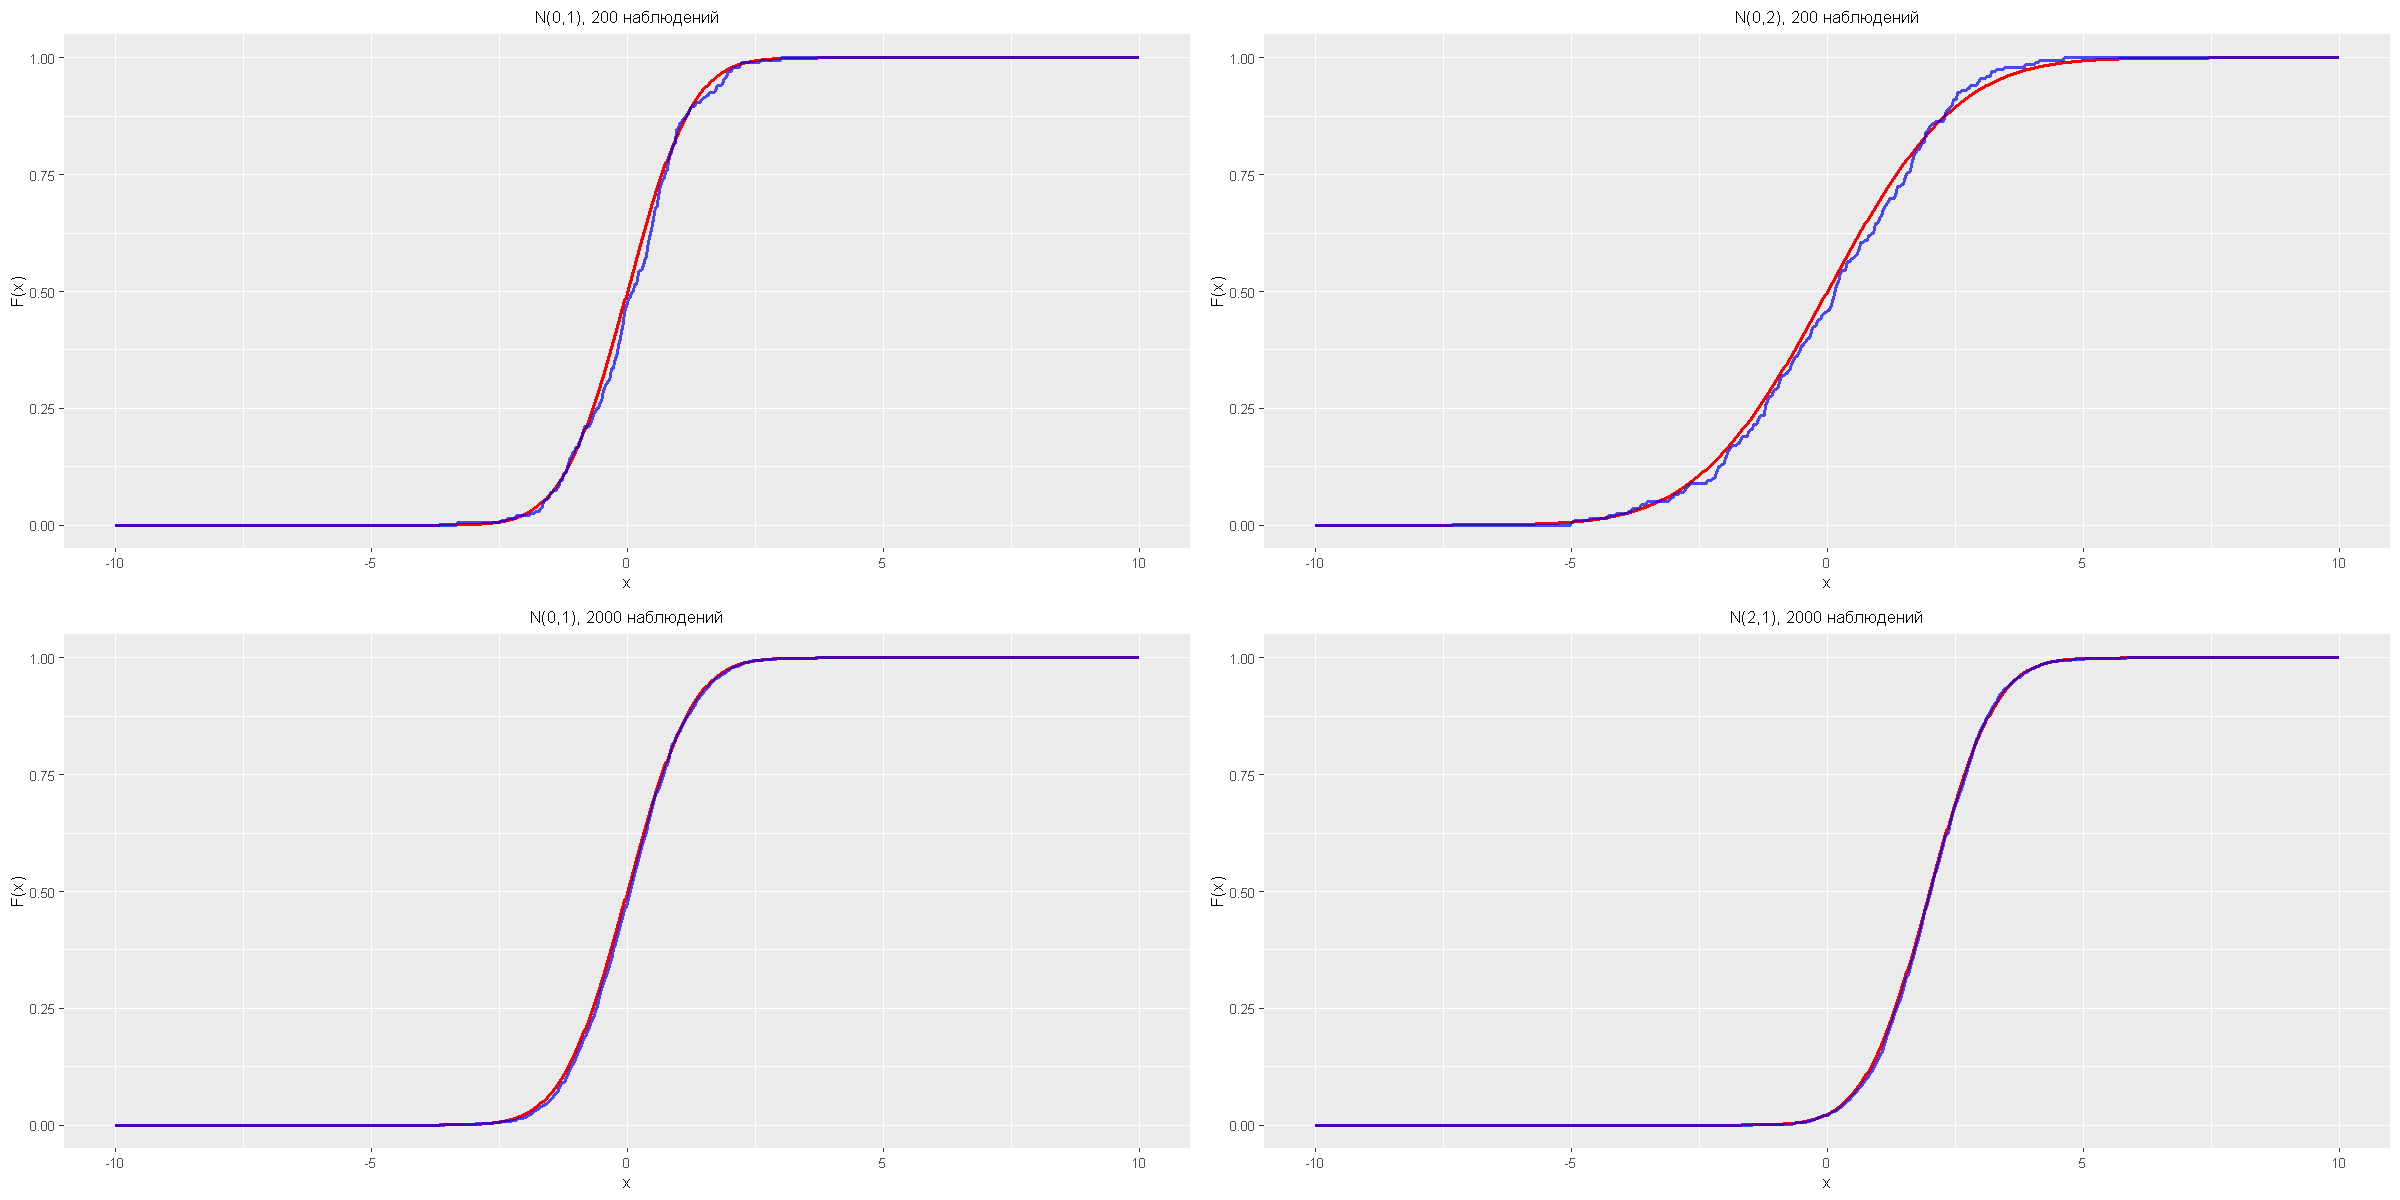

In [34]:
x <- seq(-10, 10, length.out = 1000)

# Функция для создания отдельных графиков
create_ecdf_plot <- function(data, theoretical_mean = 0, theoretical_sd = 1, title = "") {
  # Теоретическая функция распределения
  theoretical_cdf <- pnorm(x, mean = theoretical_mean, sd = theoretical_sd)
  
  # Эмпирическая функция распределения
  ecdf_func <- ecdf(data)
  empirical_cdf <- ecdf_func(x)
  
  # Создаем dataframe для ggplot
  plot_data <- data.frame(
    x = x,
    theoretical = theoretical_cdf,
    empirical = empirical_cdf
  )
  
  ggplot(plot_data) +
    geom_line(aes(x = x, y = theoretical), color = "red", size = 1) +
    geom_line(aes(x = x, y = empirical), color = "blue", size = 1, alpha = 0.7) +
    labs(
      title = title,
      x = "x",
      y = "F(x)"
    ) +
    theme(
      plot.title = element_text(size = 10, hjust = 0.5),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 8)
    ) +
    xlim(-10, 10) +
    ylim(0, 1)
}

# Создаем 4 графика
p1 <- create_ecdf_plot(data1, 0, 1, "N(0,1), 200 наблюдений")
p2 <- create_ecdf_plot(data2, 0, 2, "N(0,2), 200 наблюдений") 
p3 <- create_ecdf_plot(data3, 0, 1, "N(0,1), 2000 наблюдений")
p4 <- create_ecdf_plot(data4, 2, 1, "N(2,1), 2000 наблюдений")

# Комбинируем в одну фигуру
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Метод квантилей

<h4>Описание метода квантилей</h4>

<p><strong>Метод квантилей</strong> - это статистический подход, основанный на сравнении квантилей двух распределений. Квантиль - это значение, ниже которого попадает определенная доля наблюдений в выборке. Например, медиана - это квантиль 0.5. Зачастую под методм квантилей подразумевается график квантиль-квантиль.

<strong>Q-Q plot </strong> - это графический метод для проверки гипотезы о том, что выборка происходит из определенного теоретического распределения. Способ построения квантиль-квантиль графика таков:
<ul>
    <li>Берутся выборочные квантили данных.</li>
    <li>Рассчитываются теоретические квантили для предполагаемого распределения на тех же вероятностях.</li>
    <li>Каждая точка на графике имеет координаты (теоретический квантиль, выборочный квантиль).</li>
</ul>
Если точки легли примерно на прямую линию (особенно на линию y=x), это сильный признак того, что данные действительно следуют предполагаемому теоретическому распределению.
</p>

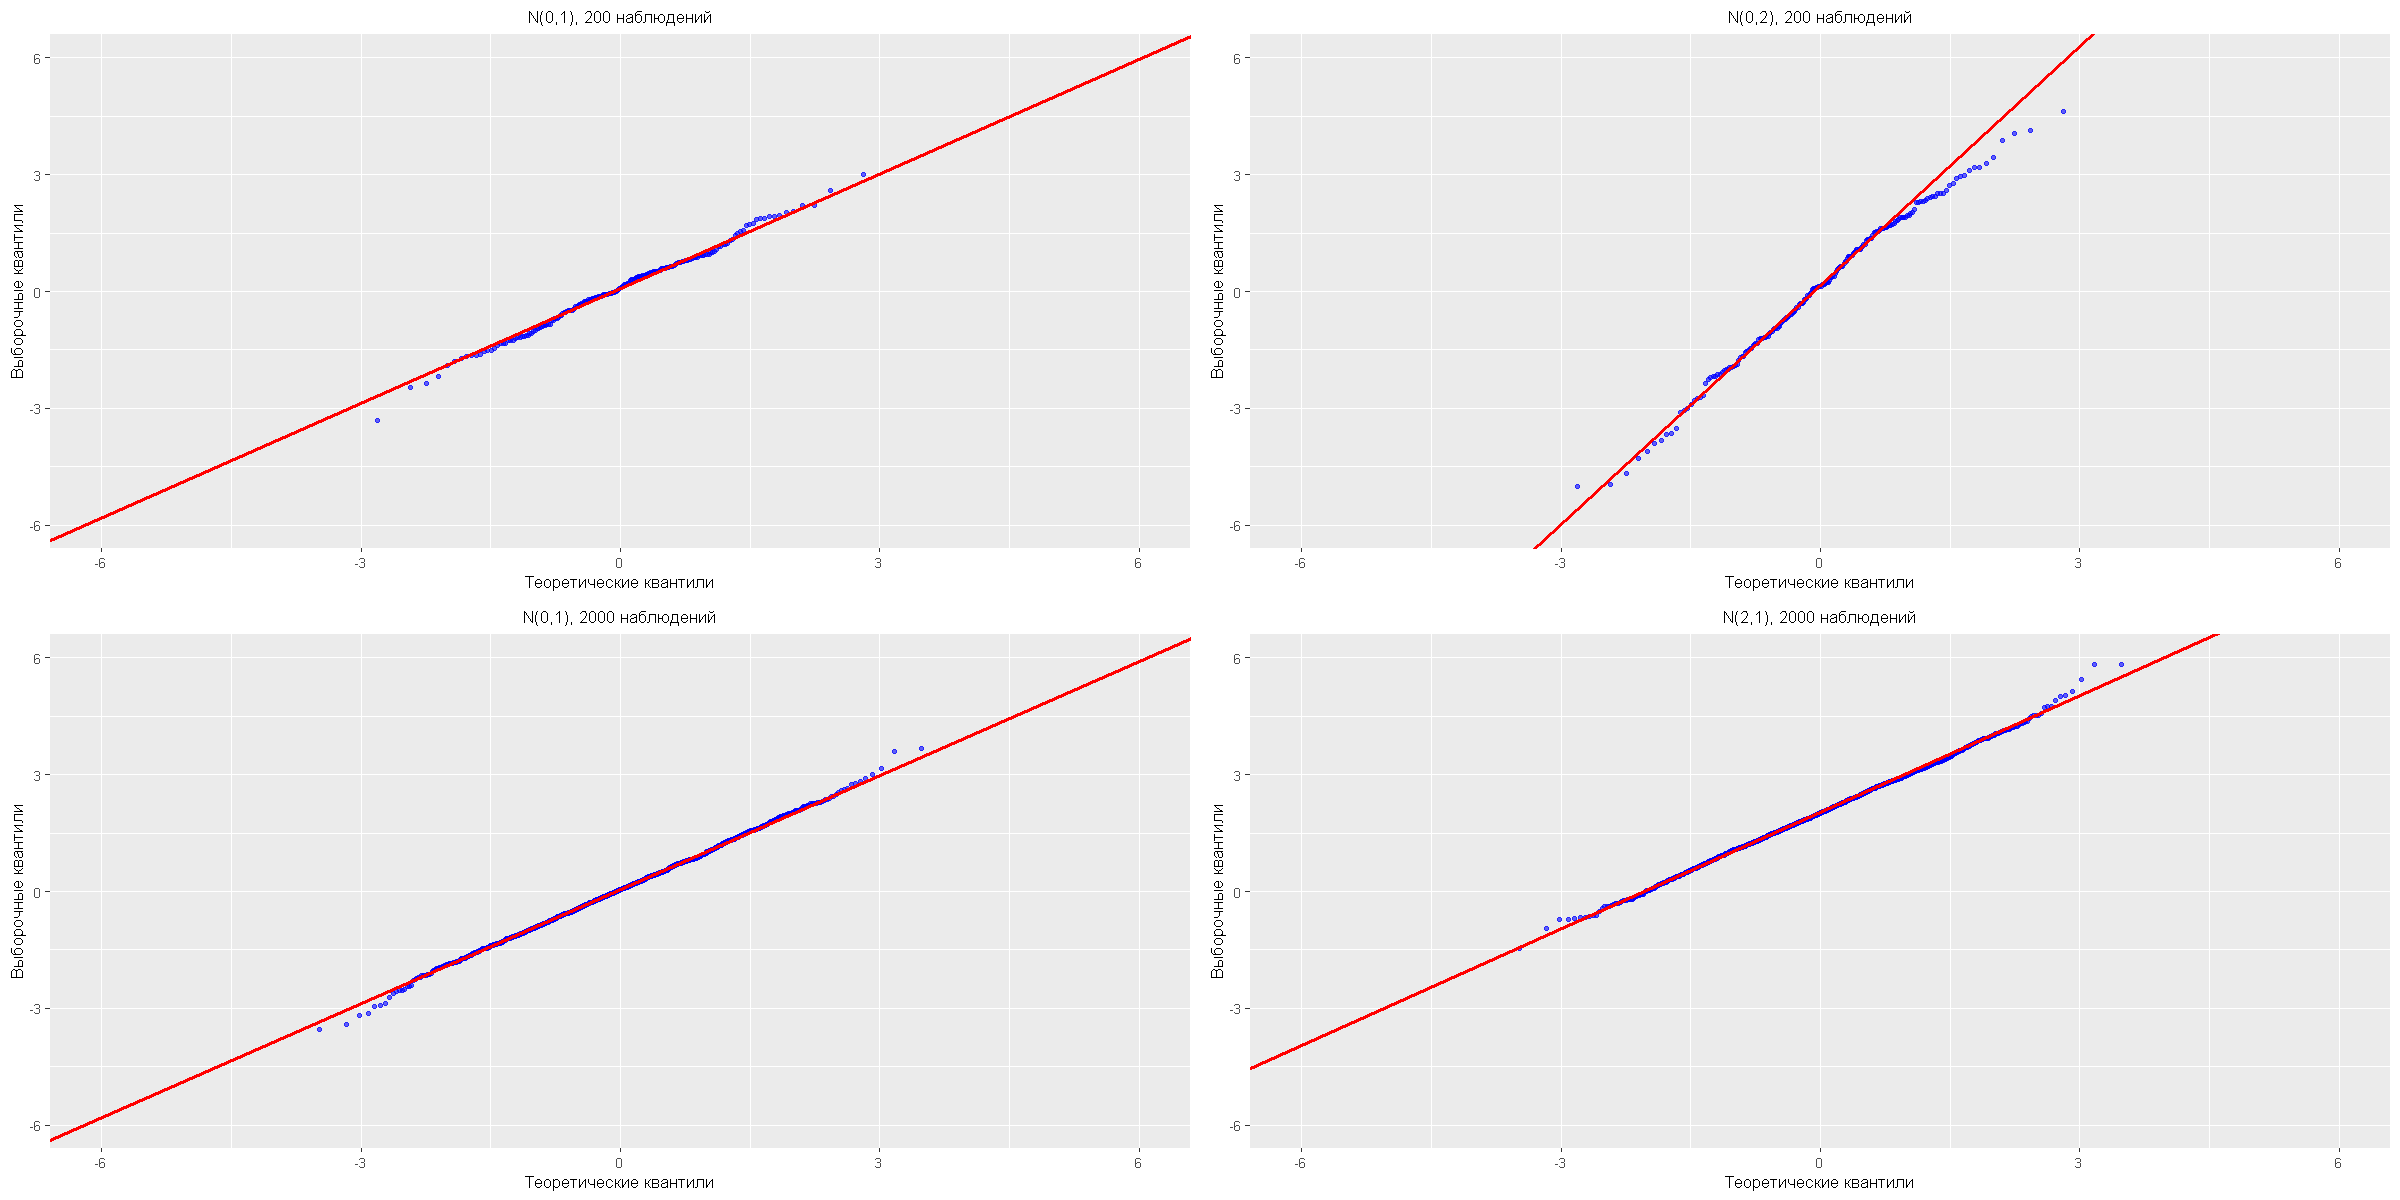

In [36]:
create_qq_plot <- function(data, title = "") {
  # Создаем Q-Q plot
  ggplot(data.frame(sample = data), aes(sample = sample)) +
    stat_qq(size = 1, color = "blue", alpha = 0.6) +
    stat_qq_line(color = "red", size = 1) +
    labs(
      title = title,
      x = "Теоретические квантили",
      y = "Выборочные квантили"
    ) +
    theme(
      plot.title = element_text(size = 10, hjust = 0.5),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 8)
    ) +
    xlim(-6, 6) +
    ylim(-6, 6)
}

# Создаем 4 графика
p1 <- create_qq_plot(data1, "N(0,1), 200 наблюдений")
p2 <- create_qq_plot(data2, "N(0,2), 200 наблюдений")
p3 <- create_qq_plot(data3, "N(0,1), 2000 наблюдений")
p4 <- create_qq_plot(data4, "N(2,1), 2000 наблюдений")

# Комбинируем в одну фигуру
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Метод огибающих

<h4> Описание метода огибающей</h4>

<p><strong>Метод огибающей</strong> - это статистический метод, который позволяет оценить, насколько эмпирическое распределение данных соответствует теоретическому, с помощью построения доверительных границ вокруг ожидаемого соотношения. Алгортитм применения этого метода такой:
<ul>
    <li>Предположим, что данные следуют теоретическому распределению F</li>
    <li>Строим статистику для выборки (например, квантили)</li>
    <li>Найдем доверительные границы</li>
    <li>Сравним реальные данные с этими границами.</li>
</ul>
    
</p>

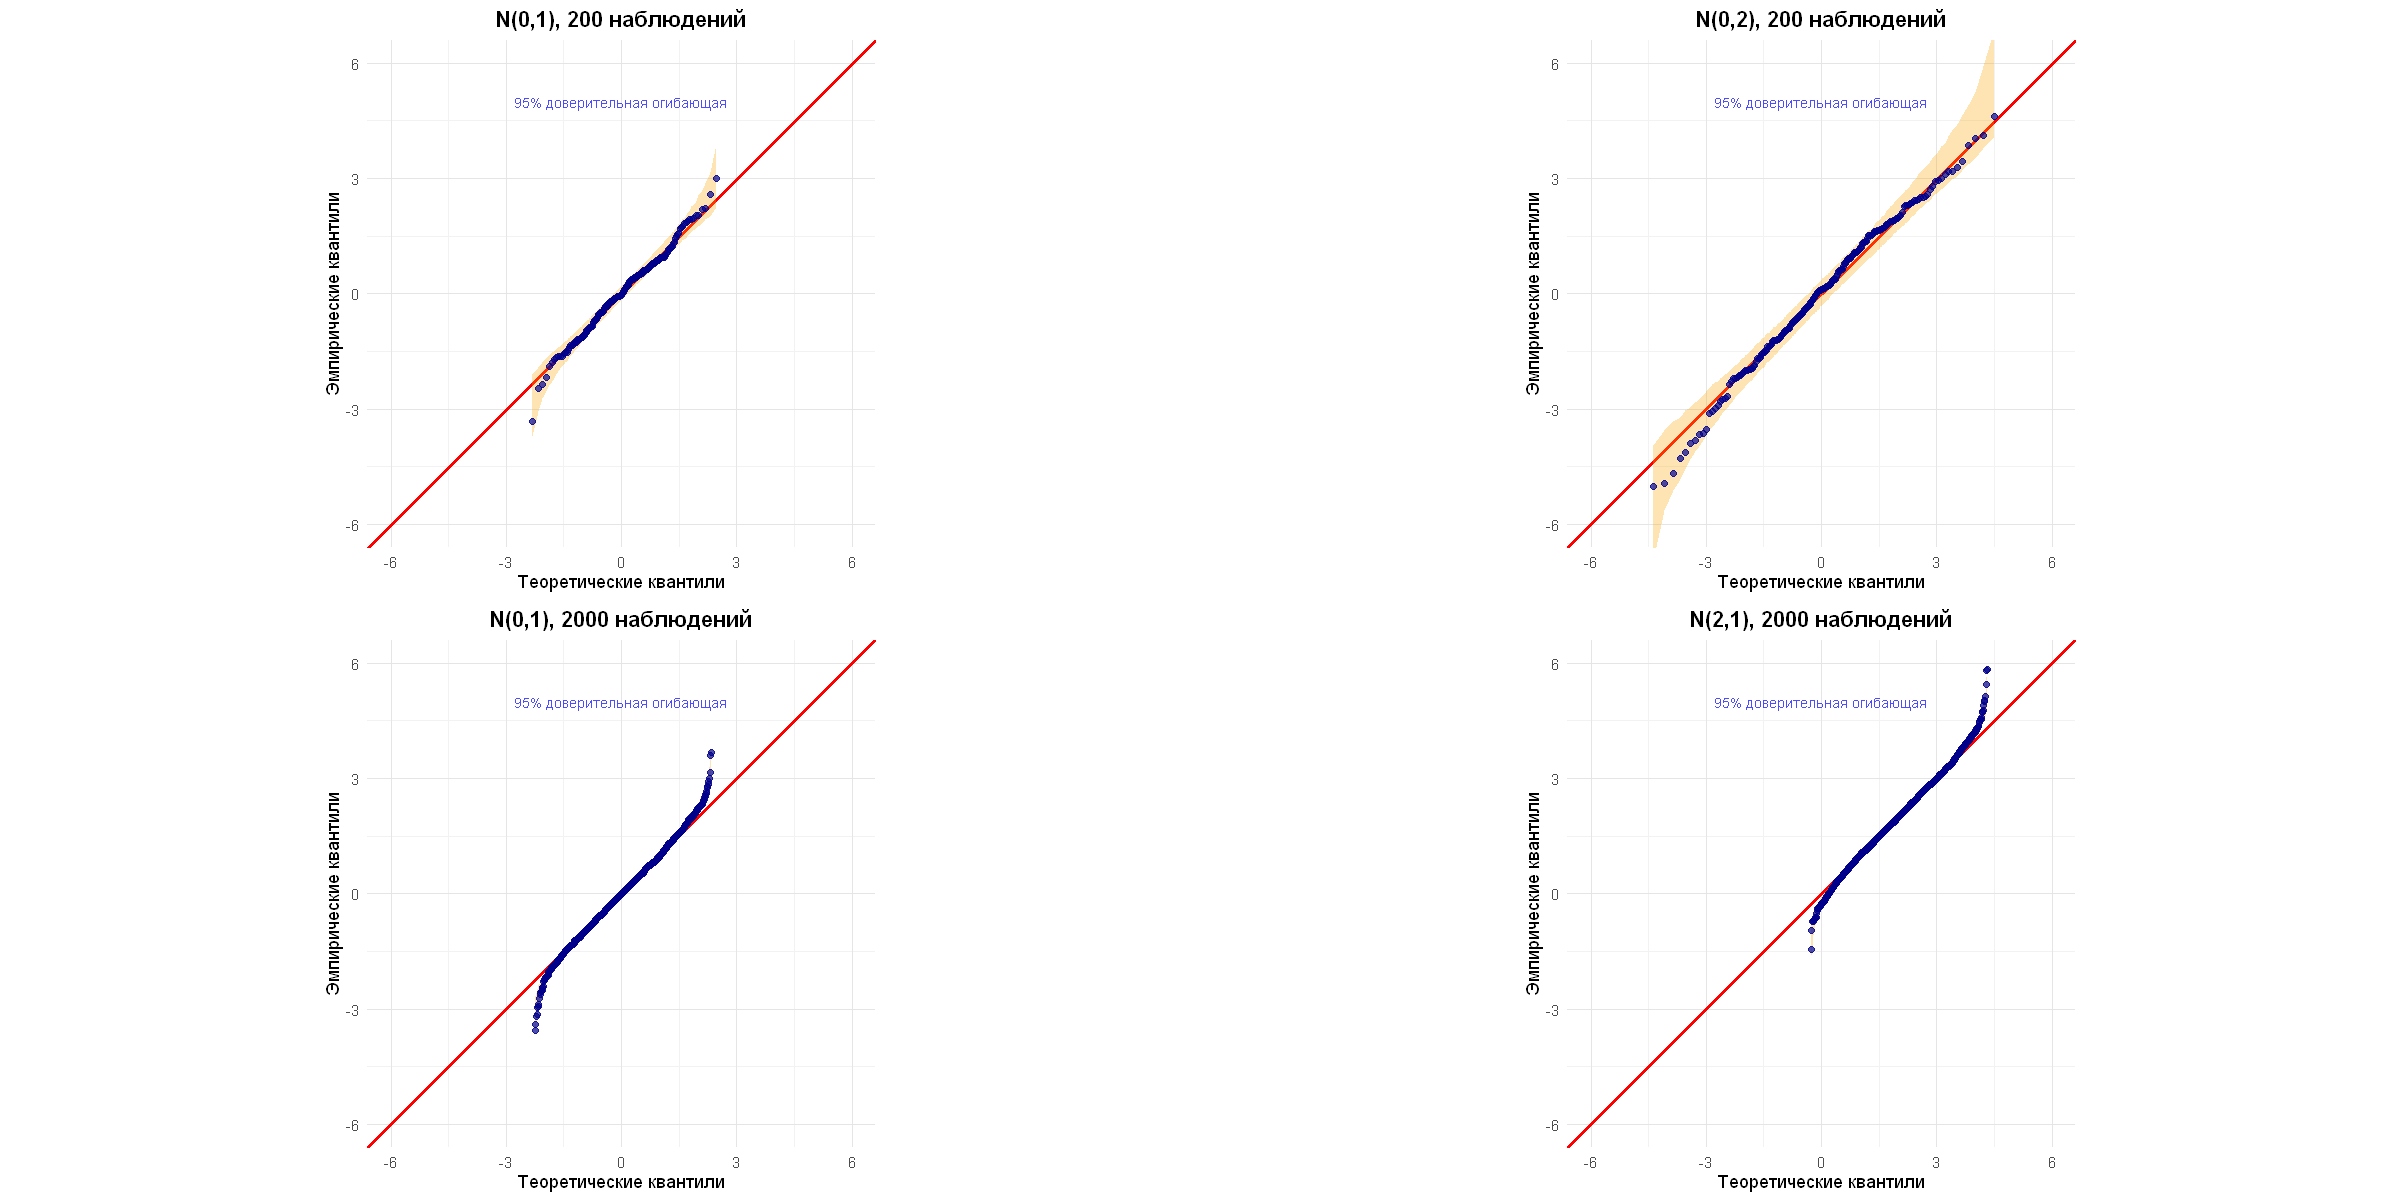

In [40]:
# Функция для метода огибающей
envelope_method <- function(data, dist = "norm", alpha = 0.05, n_sim = 1000, title = "") {
  # Сортируем данные
  data_sorted <- sort(data)
  n <- length(data_sorted)
  
  # Теоретические квантили
  # Оцениваем параметры нормального распределения
  mu <- mean(data)
  sigma <- sd(data)
  theoretical_quantiles <- qnorm(seq(0.01, 0.99, length.out = n), mu, sigma)

  # Генерируем симуляции для построения огибающей
  envelope_matrix <- matrix(0, nrow = n_sim, ncol = n)
  
  for (i in 1:n_sim) {
    # Генерируем данные из теоретического распределения
    sim_data <- rnorm(n, mu, sigma)
    envelope_matrix[i, ] <- sort(sim_data)
  }
  
  # Вычисляем процентили для огибающей
  lower_bound <- apply(envelope_matrix, 2, function(x) quantile(x, alpha/2))
  upper_bound <- apply(envelope_matrix, 2, function(x) quantile(x, 1 - alpha/2))
  
  # Создаем dataframe для ggplot
  plot_data <- data.frame(
    theoretical = theoretical_quantiles,
    empirical = data_sorted,
    lower = lower_bound,
    upper = upper_bound
  )
  
  # Создаем график
  ggplot(plot_data, aes(x = theoretical)) +
    # Теоретическая линия
    geom_abline(slope = 1, intercept = 0, color = "red", linewidth = 1, linetype = "solid") +
    # Огибающая
    geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.3, fill = "orange") +
    # Эмпирические данные
    geom_point(aes(y = empirical), color = "darkblue", alpha = 0.7, size = 1.5) +
    labs(
      title = title,
      x = "Теоретические квантили",
      y = "Эмпирические квантили"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      panel.grid.major = element_line(color = "grey90"),
      panel.grid.minor = element_line(color = "grey95")
    ) +
    coord_fixed(ratio = 1, xlim = c(-6, 6), ylim = c(-6, 6)) +
    annotate("text", x = 0, y = 5, 
             label = paste0((1-alpha)*100, "% доверительная огибающая"),
             color = "blue", alpha = 0.7, size = 3)
}

# Создаем 4 графика
p1 <- envelope_method(data1, title = "N(0,1), 200 наблюдений")
p2 <- envelope_method(data2, title = "N(0,2), 200 наблюдений")
p3 <- envelope_method(data3, title = "N(0,1), 2000 наблюдений")
p4 <- envelope_method(data4, title = "N(2,1), 2000 наблюдений")

# Комбинируем в одну фигуру
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Критерии Колмогорова-Смирнова, Шапиро-Уилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

<h4>Краткое описание тестов:</h4>

<p><strong>Тест Шапиро-Уилка (и Шапиро-Франсиа)</strong> Рассчитан на небольшие выборки (до 5000 наблюдений). Оценивает нормальность данных, основываясь на линейности Q-Q графика.

<strong>Тест Андерсона-Дарлинга</strong> Использует взвешенные отклонения эмпирической функции распределения от теоретической. Подходит для малых и средних выборок.

<strong>Критерий Крамера-фон Мизеса</strong> Проверяет согласованность эмпирической функции распределения с теоретической, суммируя отклонения. Более чувствителен к отклонениям в середине распределения.

<strong>Тест Колмогорова-Смирнова</strong> Использует максимальное отклонение эмпирической функции распределения от теоретической. Подходит для любого объёма выборки.

<strong>Модификация Лиллиефорса теста Колмогорова-Смирнова</strong> Учитывает отклонения эмпирической функции распределения от нормального распределения, где параметры (среднее и дисперсия) оцениваются из выборки.
</p>

In [41]:
printresults <- function(p_value, name, alpha = 0.05) {
  cat(name, "\n")
  cat("    p-value =", p_value, "\n")
  cat("    Есть ли основания отбросить гипотезу?", ifelse(p_value < alpha, "Да", "Нет"), "\n")
}


In [42]:
# Установка необходимых пакетов
if (!requireNamespace("nortest", quietly = TRUE)) install.packages("nortest")
if (!requireNamespace("stats", quietly = TRUE)) install.packages("stats")
if (!requireNamespace("goftest", quietly = TRUE)) install.packages("goftest")

library(nortest)
library(stats)
library(goftest)

printresults <- function(p_value, name, alpha = 0.05) {
  cat(name, "\n")
  cat("    p-value =", round(p_value, 6), "\n")
  cat("    Есть ли основания отбросить гипотезу?", 
      ifelse(p_value < alpha, "Да", "Нет"), "\n\n")
}

Data <- list(data1, data2, data3, data4)
Names <- c('N(0,1), 200 наблюдений:', 'N(0,2), 200 наблюдений:', 
           'N(0,1), 2000 наблюдений:', 'N(2,1), 2000 наблюдений:')


Присоединяю пакет: 'goftest'


Следующие объекты скрыты от 'package:nortest':

    ad.test, cvm.test




In [46]:
cat("\nСмирнов-Колмогоров\n")
for (i in seq_along(Data)) {
  test_result <- ks.test(Data[[i]], "pnorm", mean(Data[[i]]), sd(Data[[i]]))
  printresults(test_result$p.value, Names[i])
}

cat("\nШапиро-Уилк\n")
for (i in seq_along(Data)) {
  test_result <- shapiro.test(Data[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nАндерсон-Дарлинг\n")
for (i in seq_along(Data)) {
  test_result <- nortest::ad.test(Data[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nКрамер-фон Мизес (с оценкой параметров)\n")
for (i in seq_along(Data)) {
  test_result <- goftest::cvm.test(Data[[i]], null = "pnorm", 
                                   mean = mean(Data[[i]]), sd = sd(Data[[i]]))
  printresults(test_result$p.value, Names[i])
}

cat("\nЛиллиефорс\n")
for (i in seq_along(Data)) {
  test_result <- lillie.test(Data[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nШапиро-Франсия\n")
for (i in seq_along(Data)) {
  test_result <- sf.test(Data[[i]])
  printresults(test_result$p.value, Names[i])
}



Смирнов-Колмогоров
N(0,1), 200 наблюдений: 
    p-value = 0.825697 
    Есть ли основания отбросить гипотезу? Нет 

N(0,2), 200 наблюдений: 
    p-value = 0.822136 
    Есть ли основания отбросить гипотезу? Нет 

N(0,1), 2000 наблюдений: 
    p-value = 0.61833 
    Есть ли основания отбросить гипотезу? Нет 

N(2,1), 2000 наблюдений: 
    p-value = 0.975415 
    Есть ли основания отбросить гипотезу? Нет 


Шапиро-Уилк
N(0,1), 200 наблюдений: 
    p-value = 0.752419 
    Есть ли основания отбросить гипотезу? Нет 

N(0,2), 200 наблюдений: 
    p-value = 0.28201 
    Есть ли основания отбросить гипотезу? Нет 

N(0,1), 2000 наблюдений: 
    p-value = 0.662246 
    Есть ли основания отбросить гипотезу? Нет 

N(2,1), 2000 наблюдений: 
    p-value = 0.483953 
    Есть ли основания отбросить гипотезу? Нет 


Андерсон-Дарлинг
N(0,1), 200 наблюдений: 
    p-value = 0.379992 
    Есть ли основания отбросить гипотезу? Нет 

N(0,2), 200 наблюдений: 
    p-value = 0.338625 
    Есть ли основания отб

<p>Все тесты, показали, что данные, сгенерированные по нормальному распределению, имеют нормальное распределение</p>

## 7.Проверка нормальности данных датасета

### Эмпирические функции распределения

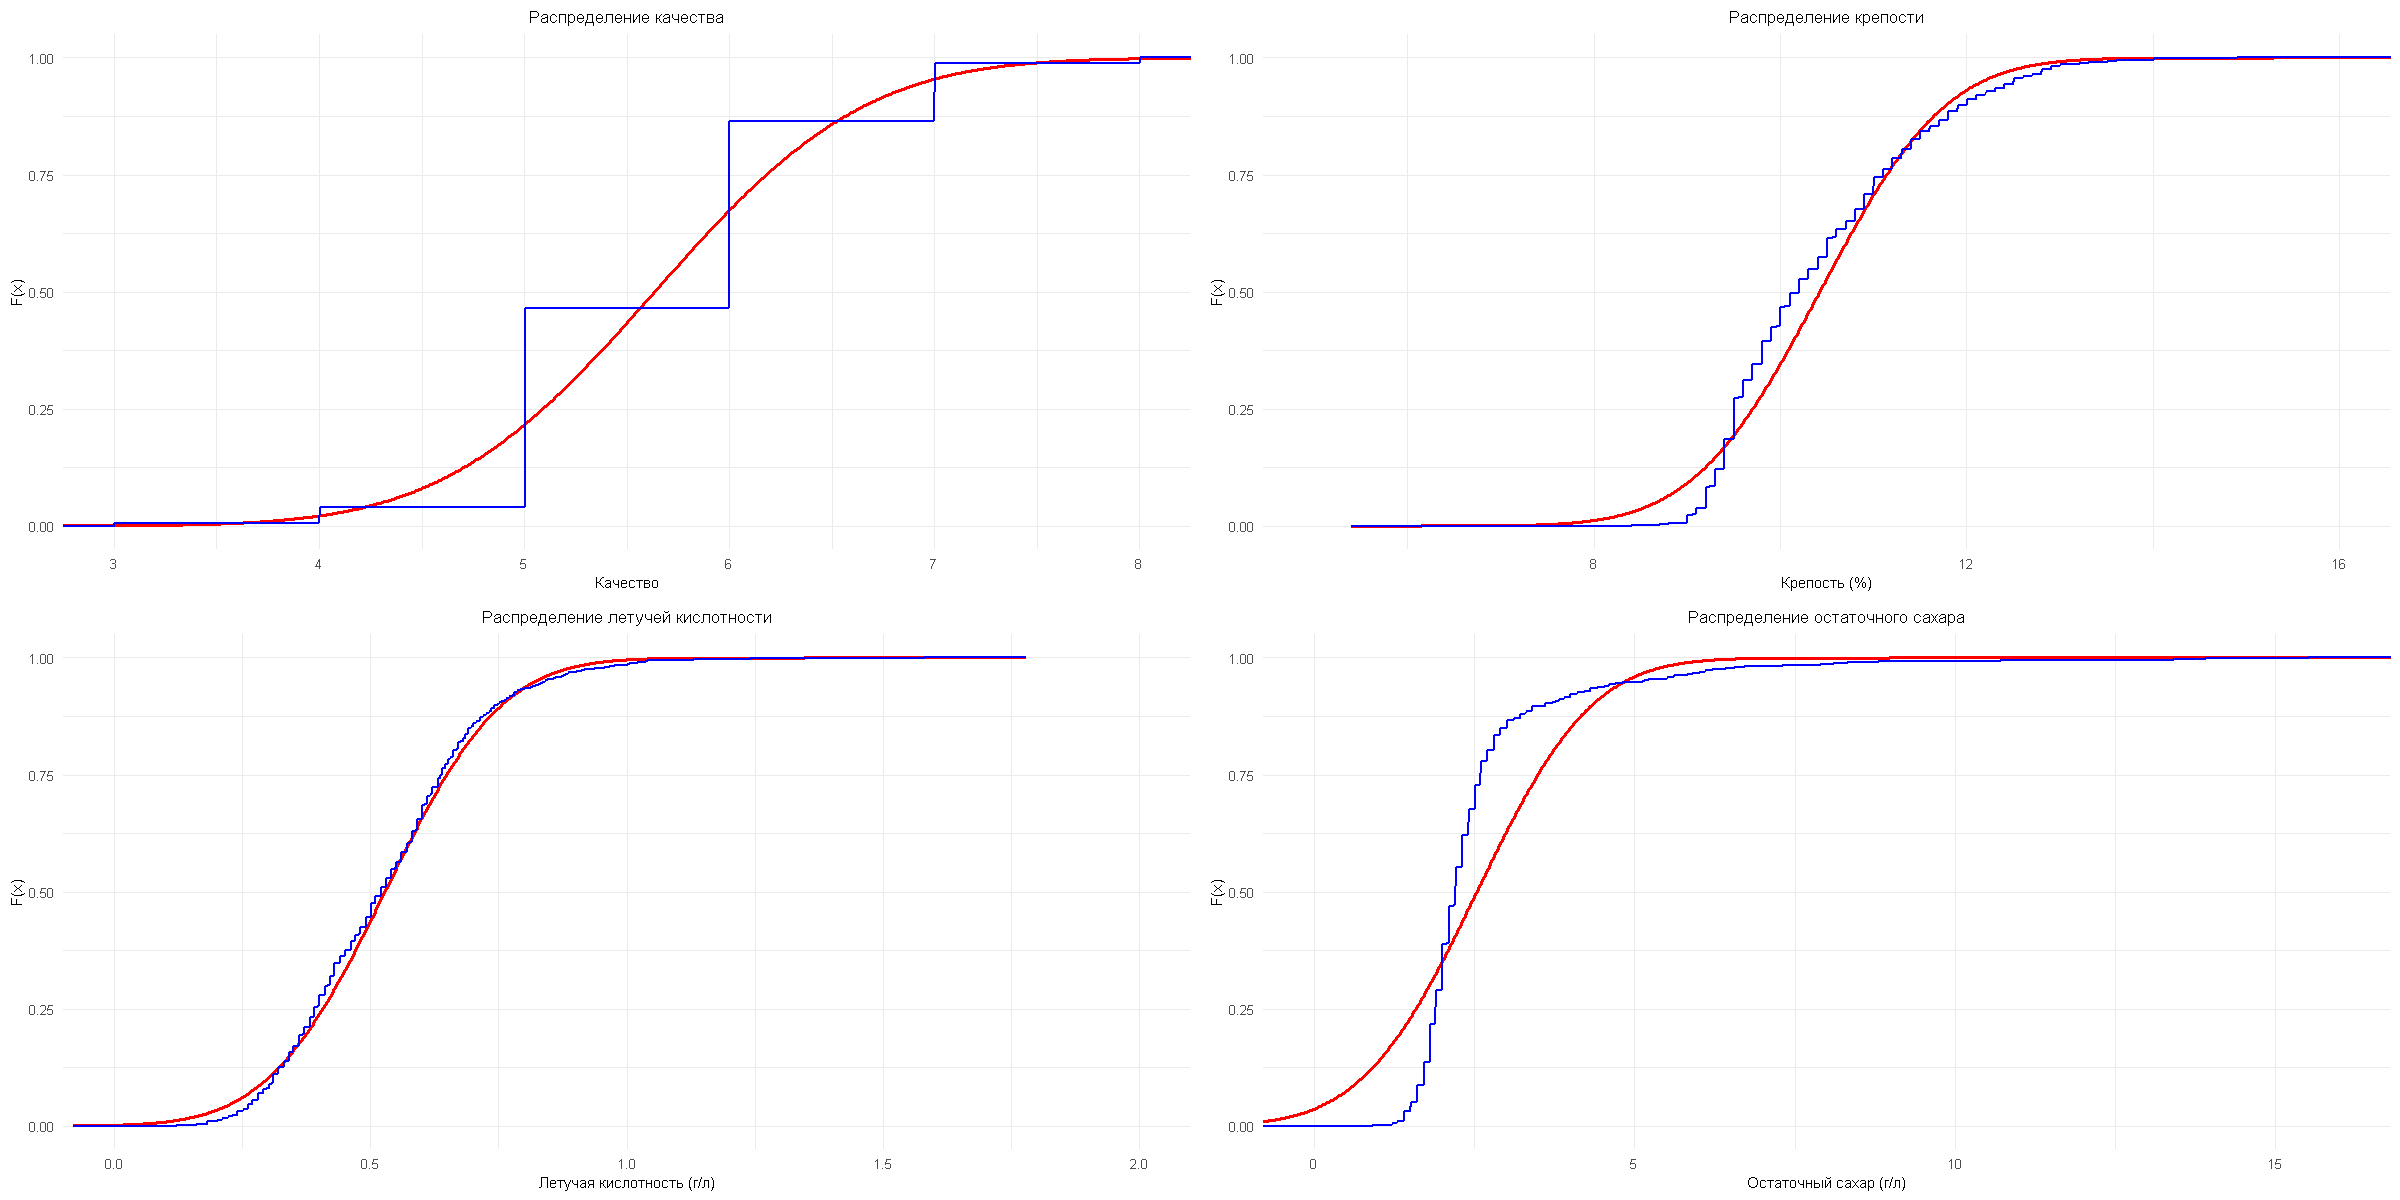

In [47]:
# Создаем последовательности для графиков
x_quality <- seq(min(wine_data$quality) - 1, max(wine_data$quality) + 1, length.out = 1000)
x_alcohol <- seq(min(wine_data$alcohol) - 3, max(wine_data$alcohol) + 3, length.out = 1000)
x_volatile_acidity <- seq(min(wine_data$volatile.acidity) - 0.2, max(wine_data$volatile.acidity) + 0.2, length.out = 1000)
x_residual_sugar <- seq(min(wine_data$residual.sugar) - 3, max(wine_data$residual.sugar) + 3, length.out = 1000)


create_ecdf_plot <- function(data, x_seq, x_limits, title, x_label = "x") {
  # Теоретическая нормальная CDF
  theoretical_cdf <- pnorm(x_seq, mean = mean(data), sd = sd(data))
  
  # Создаем dataframe для теоретической линии
  theoretical_data <- data.frame(x = x_seq, y = theoretical_cdf)
  
  # Создаем dataframe для эмпирической ECDF
  ecdf_func <- ecdf(data)
  empirical_data <- data.frame(x = x_seq, y = ecdf_func(x_seq))
  
  ggplot() +
    # Теоретическая нормальная CDF
    geom_line(data = theoretical_data, aes(x = x, y = y), color = "red", size = 1) +
    # Эмпирическая ECDF
    geom_line(data = empirical_data, aes(x = x, y = y), color = "blue", size = 0.8) +
    labs(
      title = title,
      x = x_label,
      y = "F(x)"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 10, hjust = 0.5),
      axis.title = element_text(size = 9),
      axis.text = element_text(size = 8)
    ) +
    coord_cartesian(xlim = x_limits)
}

# Создаем 4 графика
p1 <- create_ecdf_plot(
  wine_data$quality, 
  x_quality, 
  c(min(wine_data$quality), max(wine_data$quality)),
  "Распределение качества",
  "Качество"
)

p2 <- create_ecdf_plot(
  wine_data$alcohol,
  x_alcohol,
  c(5, 16),
  "Распределение крепости", 
  "Крепость (%)"
)

p3 <- create_ecdf_plot(
  wine_data$volatile.acidity,
  x_volatile_acidity, 
  c(0, 2),
  "Распределение летучей кислотности",
  "Летучая кислотность (г/л)"
)

p4 <- create_ecdf_plot(
  wine_data$residual.sugar,
  x_residual_sugar,
  c(0, 16),
  "Распределение остаточного сахара",
  "Остаточный сахар (г/л)"
)

# Комбинируем в одну фигуру
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Метод квантилей

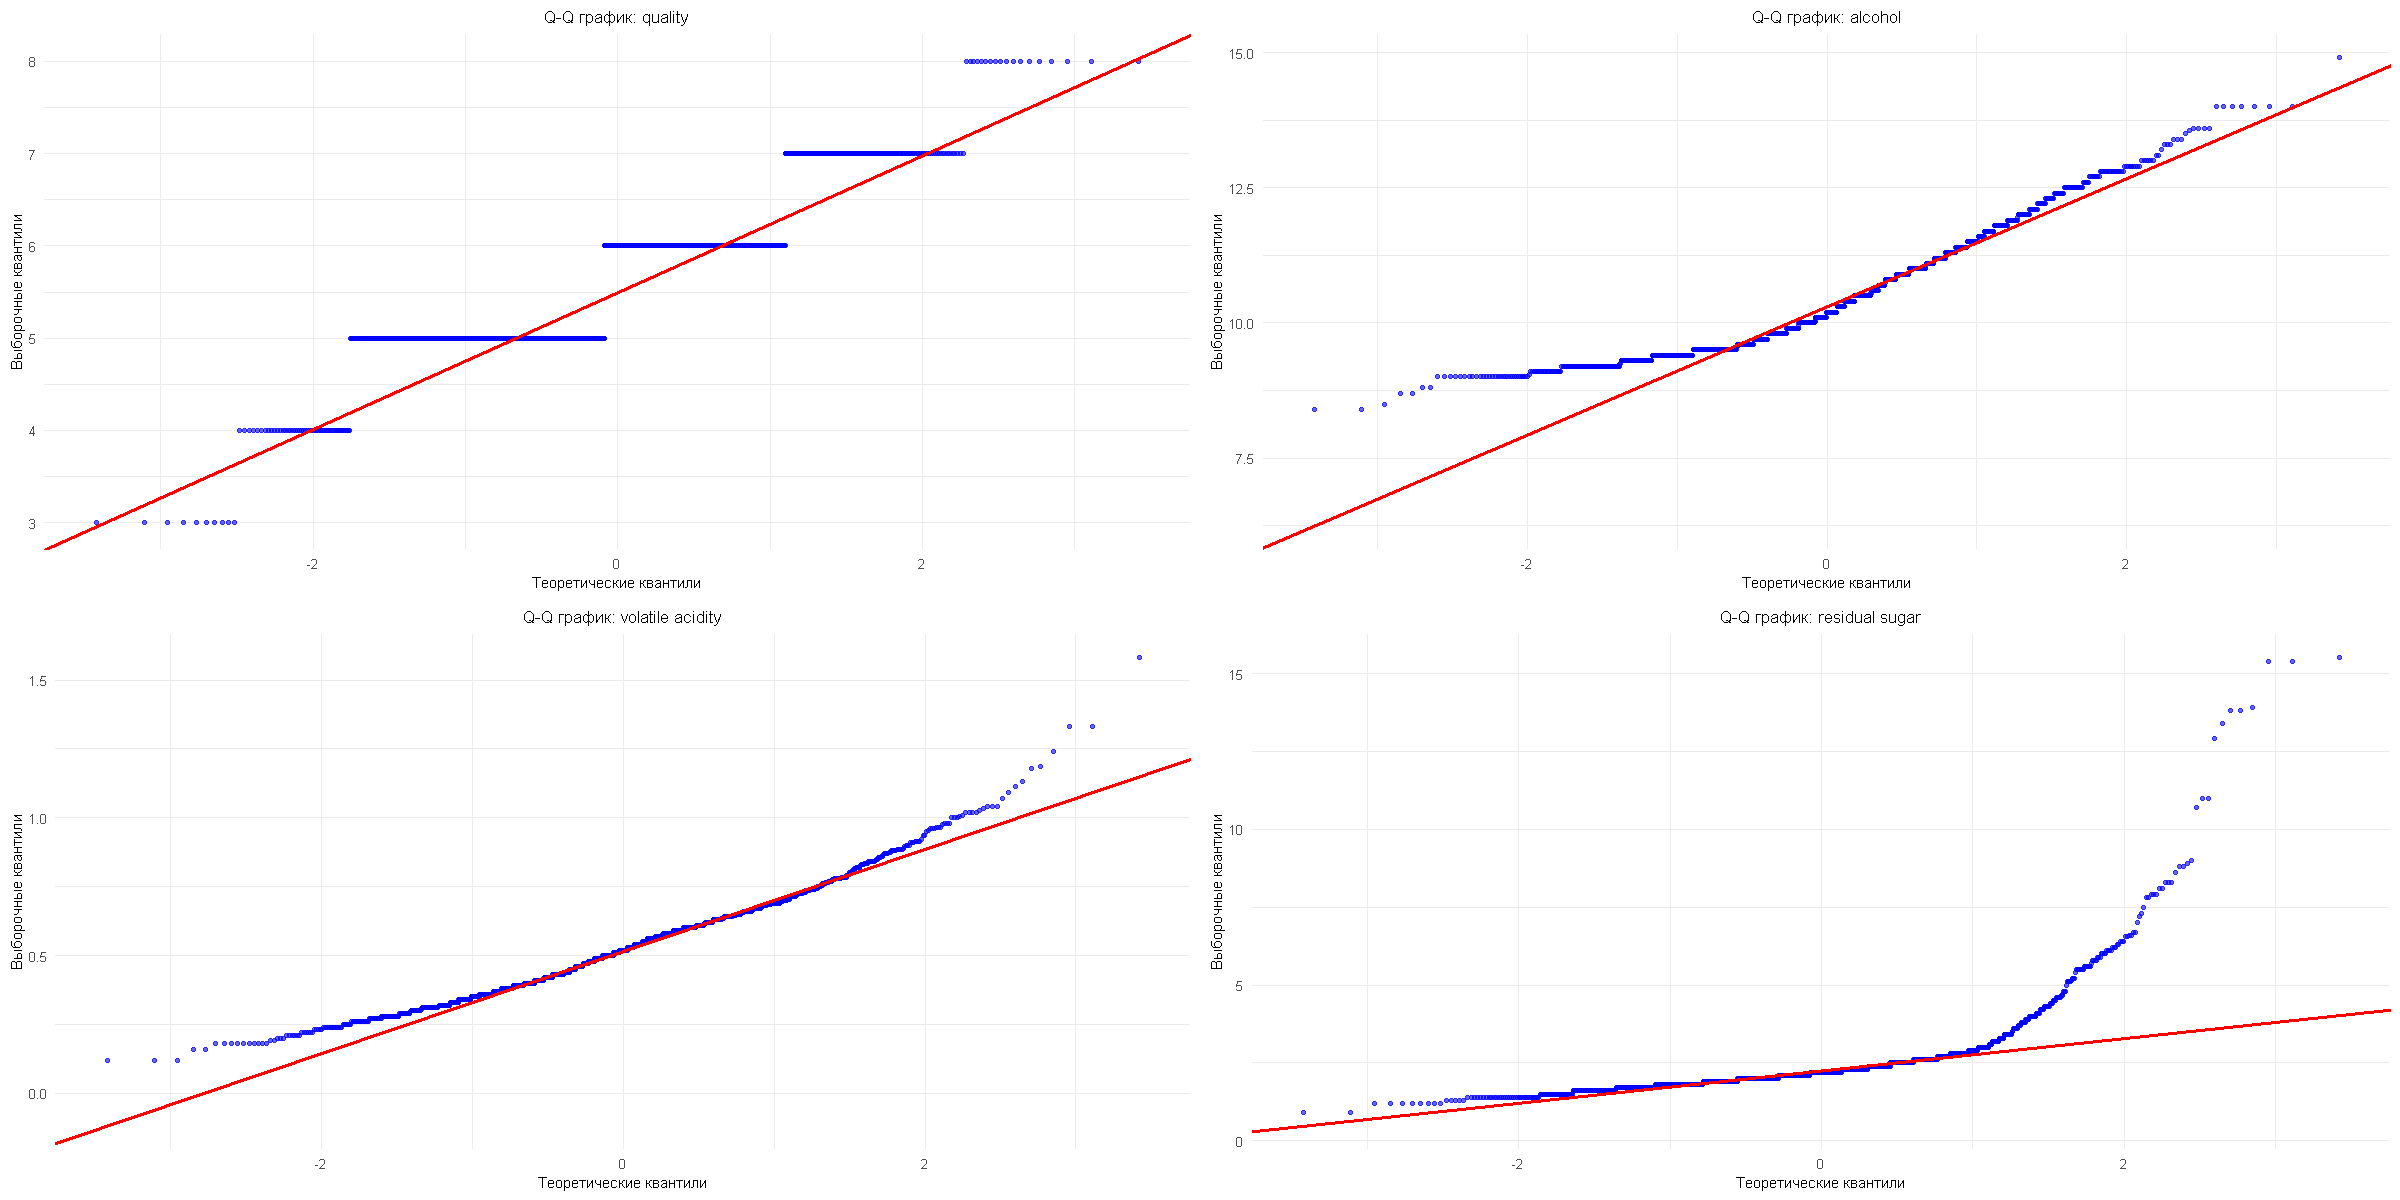

In [48]:
# Функция для создания Q-Q plot
create_qq_plot <- function(data, title = "") {
  ggplot(data.frame(sample = data), aes(sample = sample)) +
    stat_qq(size = 1, color = "blue", alpha = 0.6) +
    stat_qq_line(color = "red", size = 1) +
    labs(
      title = title,
      x = "Теоретические квантили",
      y = "Выборочные квантили"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 10, hjust = 0.5),
      axis.title = element_text(size = 9),
      axis.text = element_text(size = 8)
    )
}

# Создаем 4 графика
p1 <- create_qq_plot(wine_data$quality, "Q-Q график: quality")
p2 <- create_qq_plot(wine_data$alcohol, "Q-Q график: alcohol")
p3 <- create_qq_plot(wine_data$volatile.acidity, "Q-Q график: volatile acidity")
p4 <- create_qq_plot(wine_data$residual.sugar, "Q-Q график: residual sugar")

grid.arrange(p1, p2, p3, p4, ncol = 2)

### Метод огибающих

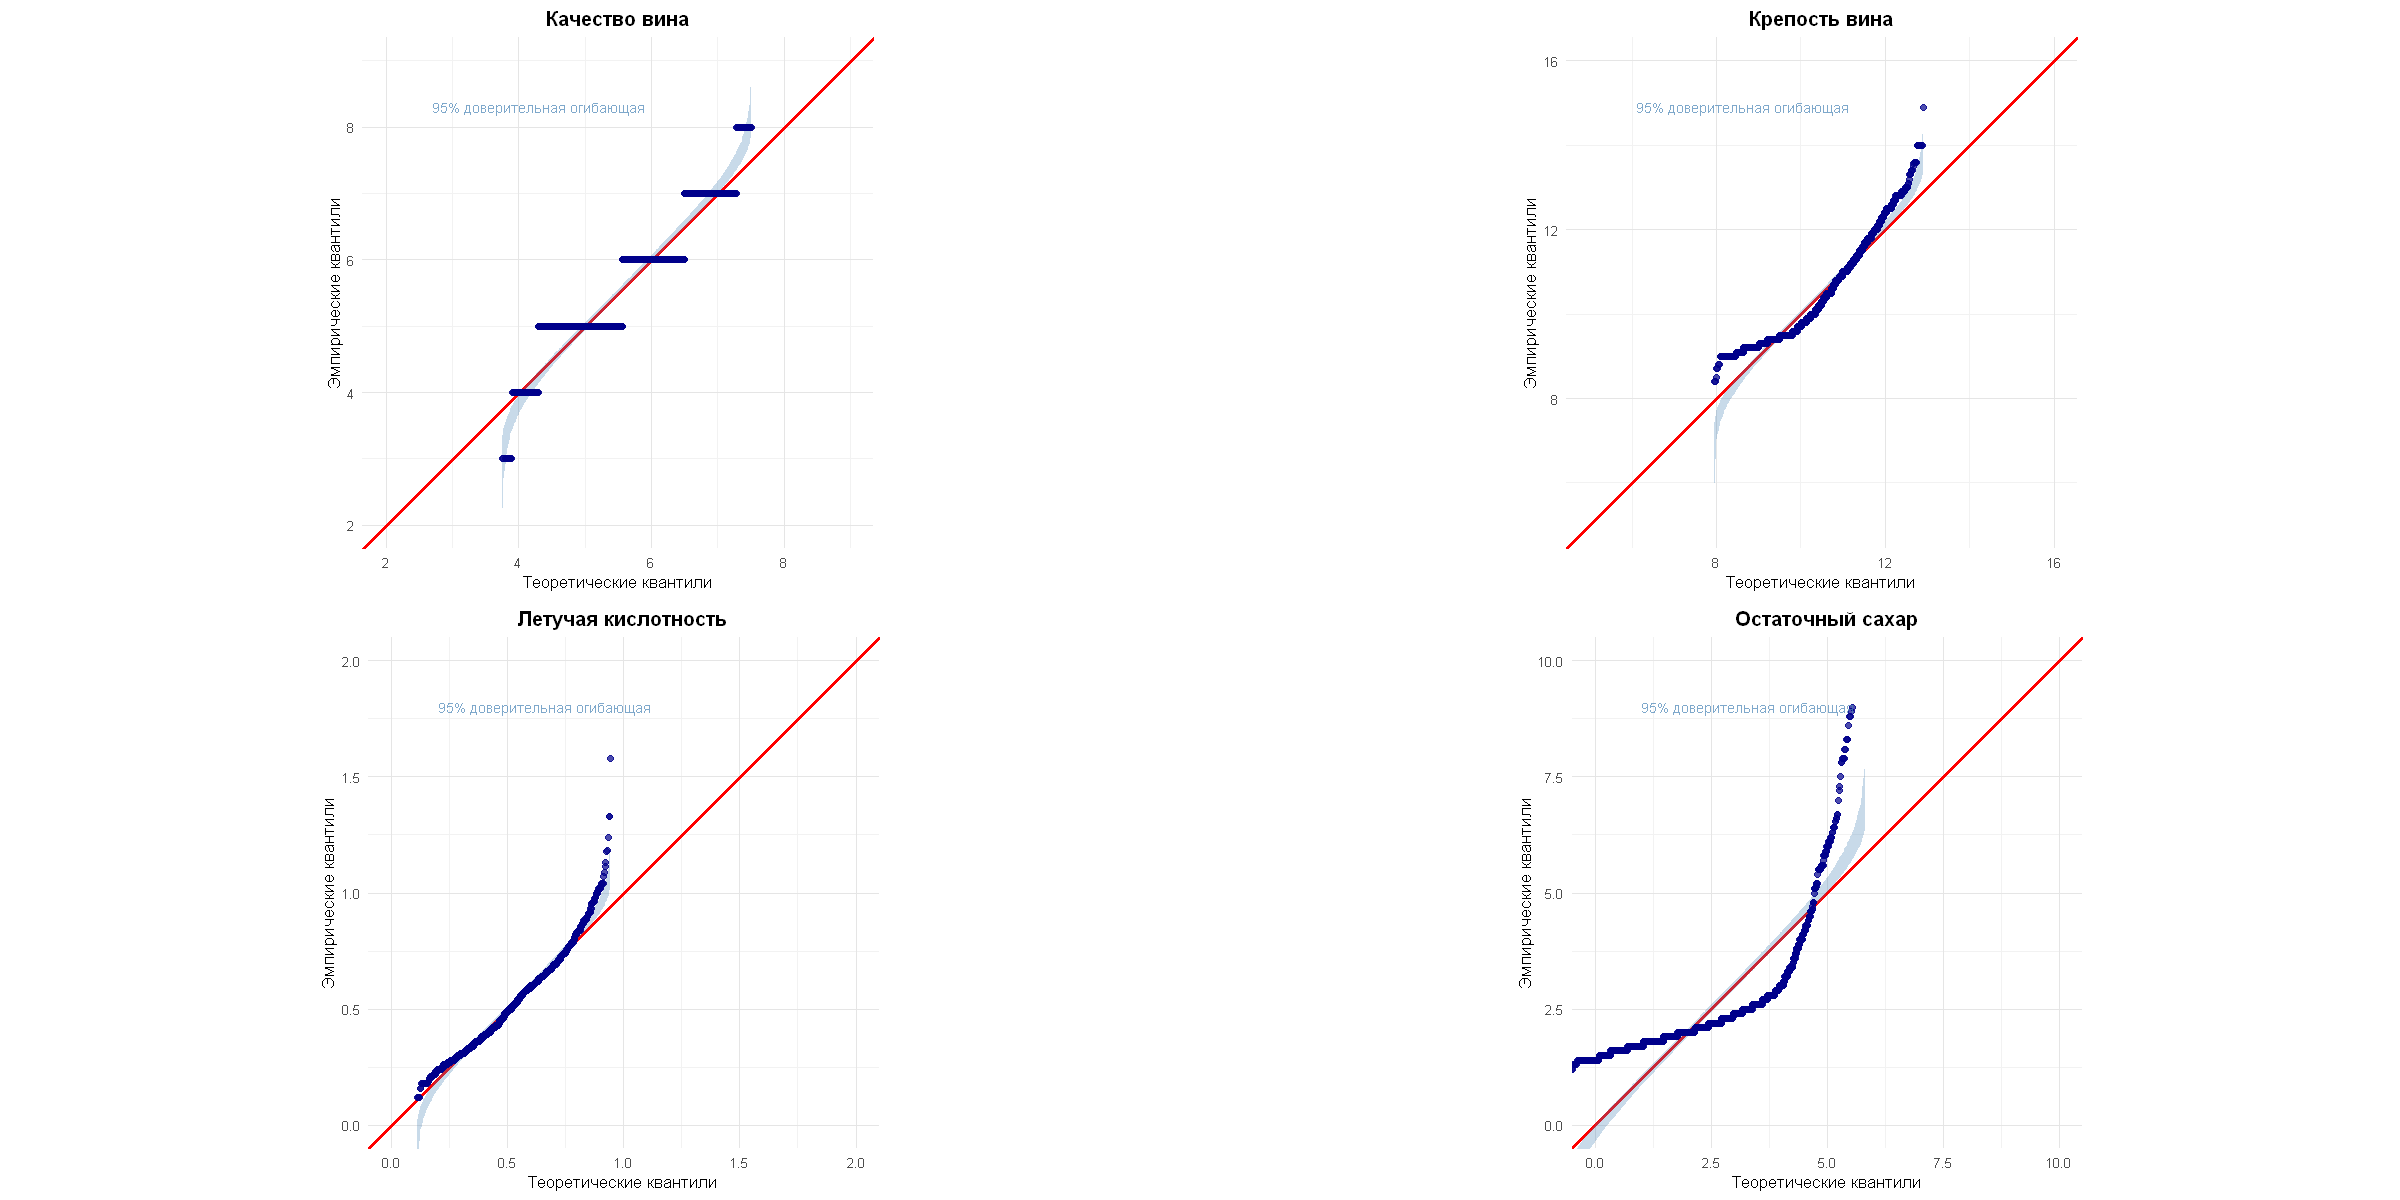

In [49]:
envelope_method <- function(data, dist = "norm", alpha = 0.05, n_sim = 1000, 
                           title = "", x_limits = NULL) {
  # Сортируем данные
  data_sorted <- sort(data)
  n <- length(data_sorted)
  
  # Теоретические квантили
  if (dist == "norm") {
    # Оцениваем параметры нормального распределения
    mu <- mean(data)
    sigma <- sd(data)
    theoretical_quantiles <- qnorm(seq(0.01, 0.99, length.out = n), mu, sigma)
  } else {
    # Для других распределений
    theoretical_quantiles <- qnorm(seq(0.01, 0.99, length.out = n))
  }
  
  # Генерируем симуляции для построения огибающей
  envelope_matrix <- matrix(0, nrow = n_sim, ncol = n)
  
  for (i in 1:n_sim) {
    # Генерируем данные из теоретического распределения
    if (dist == "norm") {
      sim_data <- rnorm(n, mu, sigma)
    } else {
      sim_data <- rnorm(n, 0, 1)
    }
    
    envelope_matrix[i, ] <- sort(sim_data)
  }
  
  # Вычисляем процентили для огибающей
  lower_bound <- apply(envelope_matrix, 2, function(x) quantile(x, alpha/2))
  upper_bound <- apply(envelope_matrix, 2, function(x) quantile(x, 1 - alpha/2))
  
  # Создаем dataframe для ggplot
  plot_data <- data.frame(
    theoretical = theoretical_quantiles,
    empirical = data_sorted,
    lower = lower_bound,
    upper = upper_bound
  )
  
  # Определяем пределы оси
  if (is.null(x_limits)) {
    # Автоматические пределы на основе данных
    data_range <- max(max(theoretical_quantiles), max(data_sorted)) - 
                  min(min(theoretical_quantiles), min(data_sorted))
    padding <- data_range * 0.1
    x_min <- min(min(theoretical_quantiles), min(data_sorted)) - padding
    x_max <- max(max(theoretical_quantiles), max(data_sorted)) + padding
    x_limits <- c(x_min, x_max)
  }
  
  # Создаем график
  p <- ggplot(plot_data, aes(x = theoretical)) +
    # Теоретическая линия
    geom_abline(slope = 1, intercept = 0, color = "red", linewidth = 1) +
    # Огибающая
    geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.3, fill = "steelblue") +
    # Эмпирические данные
    geom_point(aes(y = empirical), color = "darkblue", alpha = 0.7, size = 1.5) +
    labs(
      title = title,
      x = "Теоретические квантили",
      y = "Эмпирические квантили"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 8),
      panel.grid.major = element_line(color = "grey90"),
      panel.grid.minor = element_line(color = "grey95")
    ) +
    coord_fixed(ratio = 1, xlim = x_limits, ylim = x_limits) +
    annotate("text", x = x_limits[1] + 0.1 * diff(x_limits), 
             y = x_limits[2] - 0.1 * diff(x_limits),
             label = paste0((1-alpha)*100, "% доверительная огибающая"),
             color = "steelblue", alpha = 0.7, size = 3, hjust = 0)
  
  return(p)
}

# Создаем 4 графика с индивидуальными пределами
p1 <- envelope_method(wine_data$quality, title = "Качество вина", x_limits = c(2, 9))
p2 <- envelope_method(wine_data$alcohol, title = "Крепость вина", x_limits = c(5, 16))
p3 <- envelope_method(wine_data$volatile.acidity, title = "Летучая кислотность", x_limits = c(0, 2))
p4 <- envelope_method(wine_data$residual.sugar, title = "Остаточный сахар", x_limits = c(0, 10))

# Комбинируем в одну фигуру
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Критерии Колмогорова-Смирнова, Шапиро-Уилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

In [28]:
Data1 <- list(wine_data$quality, wine_data$alcohol, wine_data$volatile.acidity, wine_data$residual.sugar)
Names <- c('Качество вина:', 'Крепость вина:', 
           'Летучая кислотность:', 'Остаточный сахар:')

In [50]:
Data1 <- list(wine_data$quality, wine_data$alcohol, wine_data$volatile.acidity, wine_data$residual.sugar)
Names <- c('Качество вина:', 'Крепость вина:', 
           'Летучая кислотность:', 'Остаточный сахар:')

# Функция для вывода результатов (должна быть определена)
printresults <- function(p_value, name, alpha = 0.05) {
  cat(name, "\n")
  cat("    p-value =", round(p_value, 6), "\n")
  cat("    Есть ли основания отбросить гипотезу?", 
      ifelse(p_value < alpha, "Да", "Нет"), "\n\n")
}

cat("\nКолмогоров-Смирнов\n")
for (i in seq_along(Data1)) {
  test_result <- suppressWarnings(ks.test(Data1[[i]], "pnorm", mean(Data1[[i]]), sd(Data1[[i]]))) # Исправлено Dat1a на Data1
  printresults(test_result$p.value, Names[i])
}

cat("\nШапиро-Уилк\n")
for (i in seq_along(Data1)) {
  test_result <- shapiro.test(Data1[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nАндерсон-Дарлинг\n")
for (i in seq_along(Data1)) { # Исправлено Data на Data1
  test_result <- nortest::ad.test(Data1[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nКрамер-фон Мизес\n")
for (i in 1:length(Data1)) {
  if(exists("cvm.test", where="package:nortest")) {
    result <- cvm.test(Data1[[i]])
    p_value <- result$p.value
    printresults(p_value, Names[i]) # Убедитесь, что print_results определена
  }
}

cat("\nЛиллиефорс\n")
for (i in seq_along(Data1)) {
  test_result <- lillie.test(Data1[[i]])
  printresults(test_result$p.value, Names[i])
}

cat("\nШапиро-Франсия\n")
for (i in seq_along(Data1)) {
  test_result <- sf.test(Data1[[i]])
  printresults(test_result$p.value, Names[i])
}


Колмогоров-Смирнов
Качество вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Крепость вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Летучая кислотность: 
    p-value = 0.000142 
    Есть ли основания отбросить гипотезу? Да 

Остаточный сахар: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 


Шапиро-Уилк
Качество вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Крепость вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Летучая кислотность: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Остаточный сахар: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 


Андерсон-Дарлинг
Качество вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Крепость вина: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Летучая кислотность: 
    p-value = 0 
    Есть ли основания отбросить гипотезу? Да 

Остаточный сахар: 
    p-value = 0 
  

<h4>Выводы:</h4> 

<p>Как видно, почти все распределения , кроме качества вина, похожи на нормальное, однако очевидно, что критерии отвергли все распределения, так как они не являются нормальными.</p>